This notebook is used to conduct pairwise statistical tests on prediction performance metrics.



In [1]:
import pandas as pd
from scipy import stats
import json
import warnings
import collections
import numpy as np
warnings.filterwarnings('ignore')
import os
os.getcwd()
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import matplotlib.colors as mcolors 
import matplotlib.cbook as cbook 

plt.rcParams['pdf.fonttype'] = 'truetype'
#plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams["font.size"] = 8
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams.update({
    "pdf.use14corefonts": True
})

In [3]:
# attribution method test
num_folds = 10
metric_name = 'acc'
attribution_methods = ['gradcam', 'inputxgrad', 'ig', 'smoothgrad','rf_mask']
models = ['gat']#, 'dmpnn', 'pna'], 'nn', 'gat', 'rf'
targets = ['CHEMBL4616_EC50',  'CHEMBL4792_Ki', 'CHEMBL1871_Ki', 'CHEMBL2971_Ki',
 'CHEMBL239_EC50', 'CHEMBL233_Ki','CHEMBL235_EC50', 'CHEMBL231_Ki','CHEMBL218_EC50','CHEMBL244_Ki',
 'CHEMBL234_Ki','CHEMBL237_Ki','CHEMBL1862_Ki','CHEMBL4203_Ki','CHEMBL2047_EC50',
 'CHEMBL219_Ki','CHEMBL236_Ki','CHEMBL228_Ki','CHEMBL2147_Ki','CHEMBL204_Ki',
 'CHEMBL262_Ki','CHEMBL287_Ki','CHEMBL2034_Ki','CHEMBL3979_EC50','CHEMBL238_Ki','CHEMBL2835_Ki',
 'CHEMBL4005_Ki','CHEMBL237_EC50','CHEMBL264_Ki','CHEMBL214_Ki']

In [4]:
# load data from csv
df_rf = pd.read_csv('./result_rf.csv')
df_gine = pd.read_csv('./result_gine.csv')
df_gat = pd.read_csv('./result_gat.csv')
#df_nn = pd.read_csv('./result_nn.csv')
df_nn=pd.read_csv('./result_nn.csv')
df_nn_mlp = pd.read_csv('./result_mlp_att.csv')
df_uncom_ablation = pd.read_csv('./result_uncom_ablation.csv')
df_com_ablation = pd.read_csv('./result_com_ablation.csv')
#df_pna = pd.read_csv('./result_pna.csv')
#df_dmpnn = pd.read_csv('./result_dmpnn.csv')
df_all = pd.concat([df_rf, df_gine, df_gat, df_nn, df_com_ablation, df_uncom_ablation], ignore_index=True)
df = df_all


--- RMSE Analysis (based on average scores per target) ---
Plot saved to rmse_grouped_avg_per_target_comparson.pdf


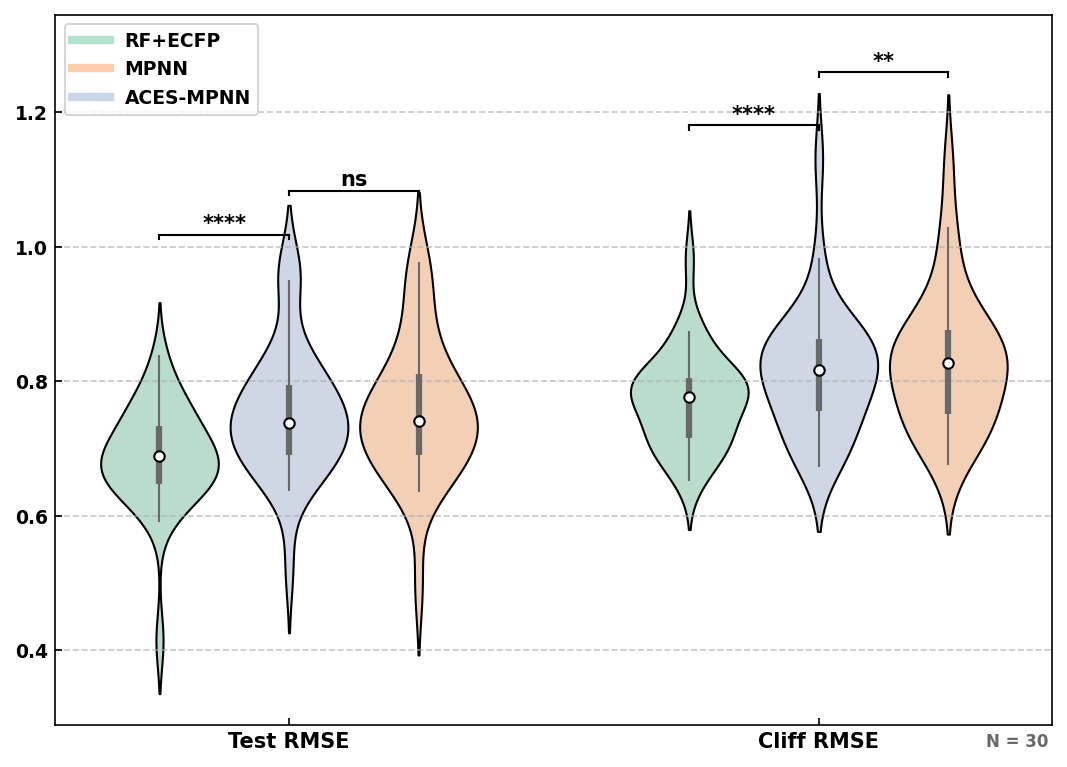


--- MAE Analysis (based on average scores per target) ---
Plot saved to mae_grouped_avg_per_target_comparison.pdf


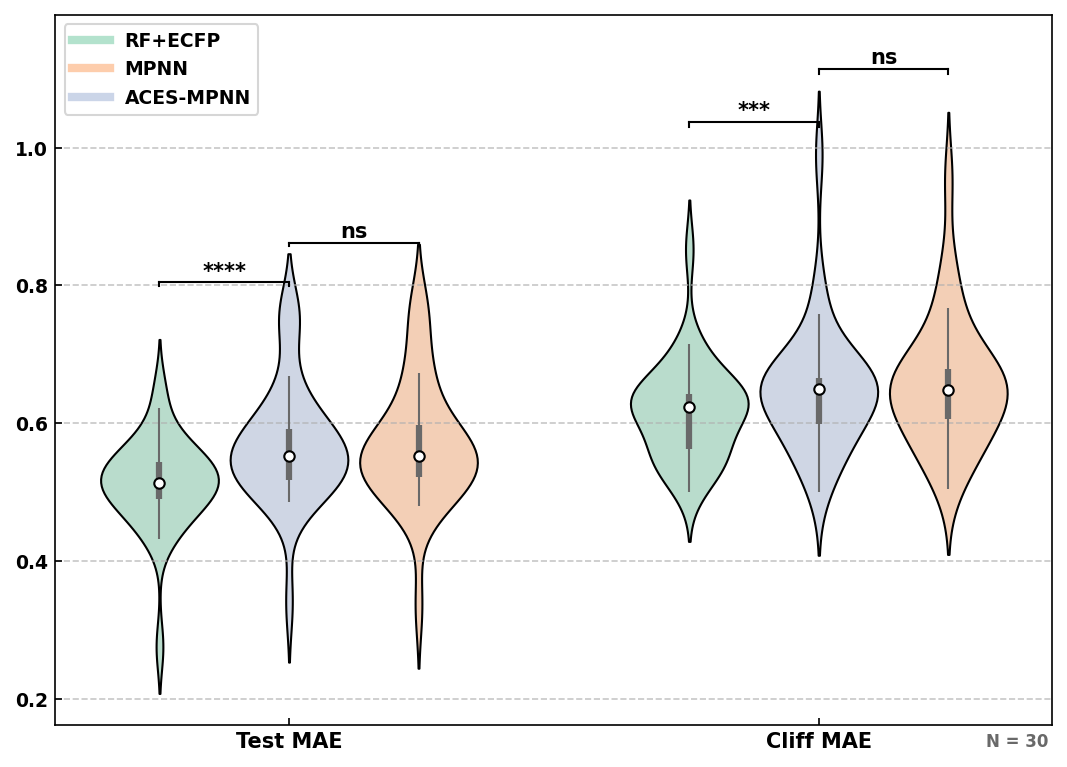


--- Attribution Analysis (All methods, Avg per Target) ---
Plot saved to attribution_all_methods_comparison.pdf


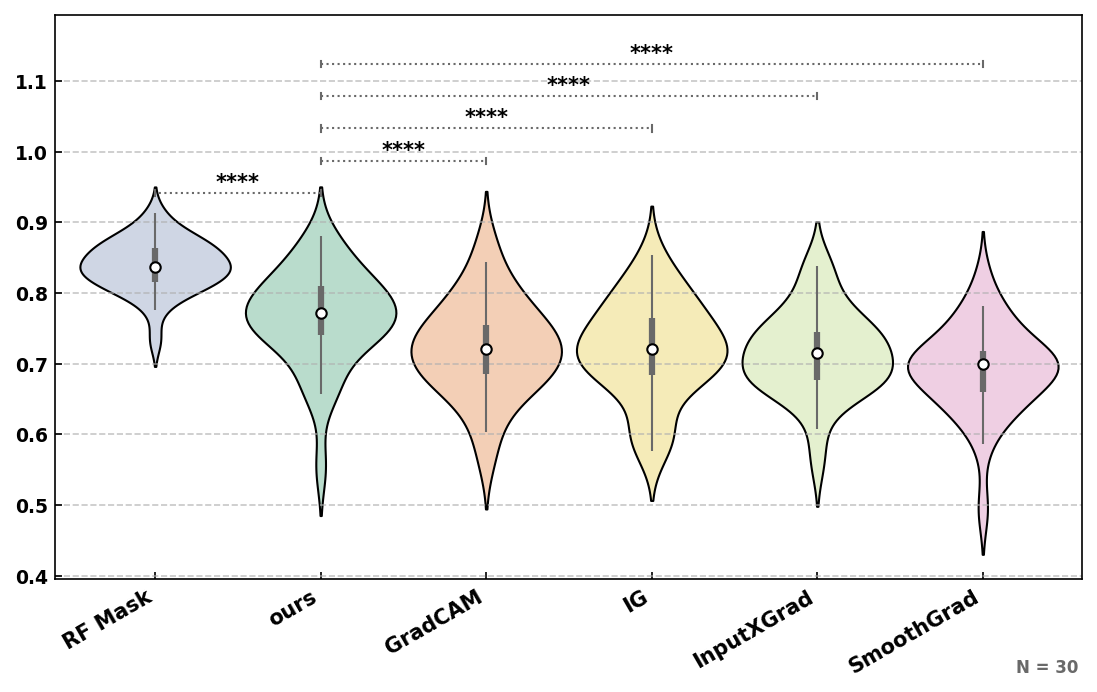


Analysis complete using average scores per target. Check for generated .png/.pdf files for plots.


In [3]:
BACKBONE_GNN = 'nn'
def plot_grouped_violins_with_sequential_tests(
    data_by_metric: dict,
    all_group_names: list,
    sort_violins_by_median: bool = True,
    sort_ascending: bool = True,
    test: str = "wilcoxon",
    alpha_levels=(0.05, 0.01, 0.001, 0.0001),
    figsize=(12, 7),
    save_path: str | None = None,
    plot_title: str = "",
    test_mode: str = "sequential",
    reference_group_name: str | None = None,
    colormap_name: str = 'Set2'
):
    """
    Plots grouped violins for multiple metrics, with groups ordered by median,
    and statistical tests annotated. Also adds a count of total comparisons made.

    Parameters
    ----------
    data_by_metric : dict
        Data structured as: {"metric_display_name1": {"group1_name": [scores], ...}, ...}
    all_group_names : list
        List of all possible group names for consistent legend/coloring.
    sort_violins_by_median : bool
        If True, violins within each metric cluster are sorted by their median score.
    sort_ascending : bool
        If sort_violins_by_median is True, this controls sort direction.
        True for ascending (lower is better), False for descending (higher is better).
    test : {"wilcoxon", "ttest_rel", "ttest_ind", "ranksums"}
        Statistical test for comparisons.
    alpha_levels : tuple
        Cut-offs for significance stars.
    figsize : tuple
        Figure size.
    save_path : str | None
        Path to save the figure.
    plot_title : str
        Title of the plot.
    test_mode : str
        "sequential": tests between adjacent sorted groups.
        "reference_vs_others": tests between a reference_group_name and all other groups.
    reference_group_name : str | None
        The group name to use as reference if test_mode is "reference_vs_others".
    colormap_name : str
        Name of the matplotlib colormap to use (e.g., 'Set2', 'Pastel1', 'Paired').
    """
    num_metrics = len(data_by_metric)
    if num_metrics == 0:
        print(f"No data provided for plotting '{plot_title}'. Skipping.")
        return

    metric_display_names = list(data_by_metric.keys())
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=150, layout="constrained")

    _tests = {
        "wilcoxon": lambda a, b: stats.wilcoxon(a, b, alternative="two-sided"),
        "ttest_rel": lambda a, b: stats.ttest_rel(a, b, alternative="two-sided"),
        "ttest_ind": lambda a, b: stats.ttest_ind(a, b, alternative="two-sided", equal_var=False), # Welch's t-test
        "ranksums": lambda a, b: stats.ranksums(a, b, alternative="two-sided"),
    }
    if test not in _tests:
        raise ValueError(f"Unsupported test '{test}'. Choose one of {list(_tests.keys())}")
    test_fun = _tests[test]

    # Define colors for groups for consistency using a specified colormap
    try:
        cmap = matplotlib.colormaps[colormap_name]
        palette = cmap.colors
    except AttributeError: # Older matplotlib
        cmap = plt.cm.get_cmap(colormap_name)
        palette = cmap.colors
    except KeyError: # Colormap name not found
        print(f"Warning: Colormap '{colormap_name}' not found. Using default.")
        prop_cycle = plt.rcParams['axes.prop_cycle']
        palette = prop_cycle.by_key()['color']

    group_colors = {name: palette[i % len(palette)] for i, name in enumerate(all_group_names)}

    num_groups_max = len(all_group_names)
    violin_base_width = 0.8
    
    metric_cluster_width = num_groups_max * violin_base_width 
    metric_spacing_factor = 0.45 # Adjusted for potentially wider labels if num_metrics=1
    if num_metrics == 1:
        metric_spacing_factor = 1.0 # Give more space if only one metric cluster with group names as ticks
    
    final_xtick_positions = []
    final_xtick_labels = []
    legend_handles = {}
    
    max_y_overall = -float('inf')
    last_metric_sample_size_for_annotation = 0


    for i, metric_name in enumerate(metric_display_names):
        metric_group_data = data_by_metric.get(metric_name, {})
        
        current_groups_data_untruncated = {
            gn: metric_group_data[gn] for gn in all_group_names 
            if gn in metric_group_data and metric_group_data[gn] and len(metric_group_data[gn]) > 0
        }

        if not current_groups_data_untruncated or len(current_groups_data_untruncated) < 1:
            print(f"Skipping metric '{metric_name}' in '{plot_title}': Not enough groups with data.")
            continue

        min_len = min(len(scores) for scores in current_groups_data_untruncated.values())
        if min_len == 0:
             print(f"Skipping metric '{metric_name}' due to zero-length data after filtering for '{plot_title}'.")
             continue
        if min_len > 0: # Store the sample size of the (potentially last) metric processed
            last_metric_sample_size_for_annotation = min_len
        
        truncated_data = {gn: scores[:min_len] for gn, scores in current_groups_data_untruncated.items()}
        
        group_order_for_metric = list(truncated_data.keys())
        if sort_violins_by_median and len(group_order_for_metric) > 1:
            medians = {gn: np.mean(scores) for gn, scores in truncated_data.items()}
            group_order_for_metric.sort(key=lambda gn: medians[gn], reverse=not sort_ascending)
        
        num_groups_for_this_metric = len(group_order_for_metric)
        actual_violin_width = violin_base_width / num_groups_max * 0.9 # Make violins a bit narrower than their slot

        base_x_pos_metric_cluster = i * metric_cluster_width * metric_spacing_factor
        plotted_group_x_positions = {}

        for j, group_name in enumerate(group_order_for_metric):
            scores = truncated_data[group_name]
            if not scores: continue 

            if scores: # Ensure scores is not empty before taking max
                 max_y_overall = max(max_y_overall, max(scores)) if max_y_overall > -float('inf') else max(scores)

            violin_x_offset = j * (actual_violin_width * 1.1) # Spacing between violins in a cluster
            current_violin_x = base_x_pos_metric_cluster + violin_x_offset

            # Seaborn violin plot (body only)
            color_rgb = group_colors.get(group_name, "gray")
            color_rgba = mcolors.to_rgba(color_rgb, alpha=0.7) # Apply alpha for violin body

            # Corrected sns.violinplot call:
            # Use 'x' to specify the center position for each data point in 'scores',
            # 'native_scale=True' to use these x-values as direct coordinates,
            # and 'orient="v"' for vertical violins.
            sns.violinplot(x=[current_violin_x] * len(scores), # X-coordinates for data points
                           y=scores,                           # Y-values (the actual data)
                           ax=ax,
                           orient="v",                         # Ensure vertical orientation
                           native_scale=True,                  # Use x-values as direct coordinates
                           width=actual_violin_width,          # Width in data units of the x-axis
                           color=color_rgba,
                           edgecolor='black',                  # Outline for the violin body
                           linewidth=1,                        # Thickness of the outline
                           inner=None,                         # We'll draw custom internals
                           #showfliers=False
                           )                   # Do not show fliers from violinplot itself

            # Custom internals: median dot, IQR bar, whiskers
            # Calculate stats using matplotlib's cbook for consistency with boxplot logic
            stats_list = cbook.boxplot_stats(scores)
            if stats_list: # Should always have one entry if scores is not empty
                s = stats_list[0] # Contains q1, med, q3, whislo, whishi
                
                # Draw IQR bar (thick line from Q1 to Q3)
                ax.plot([current_violin_x, current_violin_x], [s['q1'], s['q3']],
                        color='dimgray', linewidth=3, solid_capstyle='butt', zorder=3)
                
                # Draw whiskers (thinner lines) - standard 1.5*IQR
                ax.plot([current_violin_x, current_violin_x], [s['whislo'], s['q1']],
                        color='dimgray', linewidth=1, solid_capstyle='butt', zorder=3)
                ax.plot([current_violin_x, current_violin_x], [s['q3'], s['whishi']],
                        color='dimgray', linewidth=1, solid_capstyle='butt', zorder=3)
                
                # Draw median dot (white dot with black edge)
                ax.plot(current_violin_x, s['med'], marker='o', color='white',
                        markeredgecolor='black', markersize=5, zorder=4)
            
            plotted_group_x_positions[group_name] = current_violin_x
            
            if group_name not in legend_handles:
                legend_handles[group_name] = plt.Line2D([0], [0], color=color_rgb, lw=4, label=group_name) # Use original RGB for legend
        
        # X-tick logic:
        if plotted_group_x_positions:
            current_metric_group_x_coords = [plotted_group_x_positions[gn] for gn in group_order_for_metric if gn in plotted_group_x_positions]
            current_metric_group_labels = [gn for gn in group_order_for_metric if gn in plotted_group_x_positions]

            if num_metrics == 1: # If only one metric cluster, use group names as x-ticks
                final_xtick_positions.extend(current_metric_group_x_coords)
                final_xtick_labels.extend(current_metric_group_labels)
                ax.set_xlabel(metric_name, fontsize=11, fontweight="bold") # Use metric name as x-axis label
            else: # Multiple metric clusters, use metric names as x-ticks for cluster centers
                if current_metric_group_x_coords:
                     cluster_center_x = np.mean(current_metric_group_x_coords)
                     final_xtick_positions.append(cluster_center_x)
                     final_xtick_labels.append(metric_name)

        if len(group_order_for_metric) >= 2:
            current_max_y_for_metric = 0
            for gn_in_order in group_order_for_metric:
                 if truncated_data[gn_in_order]: # Check if list is not empty
                    current_max_y_for_metric = max(current_max_y_for_metric, max(truncated_data[gn_in_order]))
            
            y_lim_for_calc = ax.get_ylim()
            # Use max_y_overall if it's been updated, otherwise use current_max_y_for_metric for local context
            effective_max_y = max(y_lim_for_calc[1], max_y_overall if max_y_overall > -float('inf') else current_max_y_for_metric)
            
            annotation_start_y = current_max_y_for_metric + 0.05 * (effective_max_y - y_lim_for_calc[0])
            annotation_increment_y = 0.08 * (effective_max_y - y_lim_for_calc[0])
            bar_height = 0.015 * (effective_max_y - y_lim_for_calc[0])
            
            annotation_idx = 0

            if test_mode == "sequential":
                for k in range(len(group_order_for_metric) - 1):
                    group1_name = group_order_for_metric[k]
                    group2_name = group_order_for_metric[k+1]

                    if not (group1_name in plotted_group_x_positions and group2_name in plotted_group_x_positions):
                        continue

                    scores1 = truncated_data[group1_name]
                    scores2 = truncated_data[group2_name]
                    # total_comparisons_made = len(scores1) # This was for the N text, now handled by last_metric_sample_size
                    if not scores1 or not scores2: continue

                    try:
                        stat_val, p_value = test_fun(scores1, scores2)
                    except ValueError as e:
                        print(f"Skipping sequential test between {group1_name} and {group2_name} for {metric_name}: {e}")
                        continue
                    
                    stars = "ns"
                    if p_value <= alpha_levels[3]: stars = "****"
                    elif p_value <= alpha_levels[2]: stars = "***"
                    elif p_value <= alpha_levels[1]: stars = "**"
                    elif p_value <= alpha_levels[0]: stars = "*"
                    
                    x1_pos = plotted_group_x_positions[group1_name]
                    x2_pos = plotted_group_x_positions[group2_name]
                    
                    line_y_level = annotation_start_y + annotation_idx * annotation_increment_y
                    max_y_overall = max(max_y_overall, line_y_level + bar_height * 1.5) # Ensure annotations fit

                    ax.plot([x1_pos, x2_pos], [line_y_level, line_y_level], lw=1, color="black")
                    ax.plot([x1_pos, x1_pos], [line_y_level - bar_height/2, line_y_level], lw=1, color="black")
                    ax.plot([x2_pos, x2_pos], [line_y_level - bar_height/2, line_y_level], lw=1, color="black")
                    ax.text((x1_pos + x2_pos) / 2, line_y_level + bar_height*0.1, stars,
                            ha="center", va="bottom", fontsize=10)
                    annotation_idx += 1
                   
            elif test_mode == "reference_vs_others" and reference_group_name:
                if reference_group_name in truncated_data and reference_group_name in plotted_group_x_positions:
                    ref_scores = truncated_data[reference_group_name]
                    x_ref_pos = plotted_group_x_positions[reference_group_name]
                    # No need to set total_comparisons_made here for the N text anymore
                    other_groups_for_test = [
                        gn for gn in group_order_for_metric 
                        if gn != reference_group_name and gn in truncated_data and gn in plotted_group_x_positions
                    ]

                    for other_group_name in other_groups_for_test:
                        other_scores = truncated_data[other_group_name]
                        if not ref_scores or not other_scores: 
                            continue
                        try:
                            stat_val, p_value = test_fun(ref_scores, other_scores)                        
                        except ValueError as e:
                            print(f"Skipping reference test between {reference_group_name} and {other_group_name} for {metric_name}: {e}")
                            continue

                        stars = "ns"
                        if p_value <= alpha_levels[3]: stars = "****"
                        elif p_value <= alpha_levels[2]: stars = "***"
                        elif p_value <= alpha_levels[1]: stars = "**"
                        elif p_value <= alpha_levels[0]: stars = "*"

                        x_other_pos = plotted_group_x_positions[other_group_name]
                        
                        line_y_level = annotation_start_y + annotation_idx * annotation_increment_y
                        max_y_overall = max(max_y_overall, line_y_level + bar_height * 1.5) # Ensure annotations fit

                        ax.plot([x_ref_pos, x_other_pos], [line_y_level, line_y_level], lw=1, color="dimgray", linestyle=':')
                        ax.plot([x_ref_pos, x_ref_pos], [line_y_level - bar_height/2, line_y_level + bar_height/2], lw=1, color="dimgray") # Small vertical ticks
                        ax.plot([x_other_pos, x_other_pos], [line_y_level - bar_height/2, line_y_level + bar_height/2], lw=1, color="dimgray") # Small vertical ticks
                        
                        ax.text((x_ref_pos + x_other_pos) / 2, line_y_level + bar_height*0.1, stars,
                                ha="center", va="bottom", fontsize=10, color="black")
                        annotation_idx += 1
                else:
                    print(f"Reference group '{reference_group_name}' not found, has no data, or was not plotted for metric '{metric_name}'. Skipping reference tests.")

    ax.set_xticks(final_xtick_positions)
    rotation = 0
    ha = "center"
    if num_metrics == 1 and final_xtick_labels: # If single metric cluster, labels are group names
        # Check if labels are somewhat long to decide on rotation
        if any(len(str(label)) > 5 for label in final_xtick_labels): # Heuristic for rotation
            rotation = 30 # Less aggressive rotation
            ha = "right"
    ax.set_xticklabels(final_xtick_labels, fontsize=10, rotation=rotation, ha=ha)
    
    ax.set_ylabel("", fontsize=10)
    ax.set_title(plot_title, fontsize=12, fontweight="bold")
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    if max_y_overall > -float('inf'):
        current_ymin, _ = ax.get_ylim()
        ax.set_ylim(current_ymin, max_y_overall * 1.05) # Add a bit of padding above the highest element

    if legend_handles:
        ordered_handles = [legend_handles[name] for name in all_group_names if name in legend_handles]
        if ordered_handles:
            # Only show legend if num_metrics > 1 (i.e., not redundant with x-axis labels)
            # or if for some reason final_xtick_positions is empty for num_metrics == 1 (fallback)
            if not (num_metrics == 1 and final_xtick_positions):
                 ax.legend(handles=ordered_handles, loc="best", fontsize=9)

    plotted_metric_clusters = [mdn for mdn in metric_display_names if data_by_metric.get(mdn) and any(data_by_metric[mdn].get(gn) for gn in all_group_names if data_by_metric[mdn].get(gn))]
    
    if len(plotted_metric_clusters) == 1:
        single_cluster_name = plotted_metric_clusters[0]
        num_violins_in_single_cluster = 0
        if single_cluster_name in data_by_metric:
            # Count how many groups actually have data for this single metric
            num_violins_in_single_cluster = len([
                gn for gn in data_by_metric[single_cluster_name] 
                if data_by_metric[single_cluster_name].get(gn) and len(data_by_metric[single_cluster_name][gn]) > 0
            ])
        
        if num_violins_in_single_cluster > 1:
            ax.margins(x=0.15 / num_violins_in_single_cluster if num_violins_in_single_cluster > 0 else 0.1) # Dynamic margin
        else: 
            ax.margins(x=0.4) # Wider margin for a single violin
    else:
        # For multiple metric clusters
        ax.margins(x=0.05) 

    if last_metric_sample_size_for_annotation > 0:
        fig.text(0.99, 0.01, f"N = {last_metric_sample_size_for_annotation}",
                 ha="right", va="bottom", fontsize=8, color='dimgray',
                 transform=fig.transFigure)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Plot saved to {save_path}")
    plt.show()

df_avg_by_target = df.groupby(['target', 'method', 'x_supervis', 'metric_name'])['metric_value'] \
                     .mean() \
                     .reset_index() \
                     .rename(columns={'metric_value': 'avg_score_per_target'})

df_avg_by_target = df_avg_by_target.sort_values(
    by=['metric_name', 'method', 'x_supervis', 'target']
).reset_index(drop=True)


# --- Define group names (consistent keys for data dicts) ---
GROUP_RF = "RF+ECFP"
GROUP_NN_NO_SUPERVIS = "MPNN"
GROUP_NN_YES_SUPERVIS = "ACES-MPNN"
all_plot_groups = [GROUP_RF, GROUP_NN_NO_SUPERVIS, GROUP_NN_YES_SUPERVIS]

# --- Helper to get average scores (per target) for a specific group and metric name ---
def get_avg_scores_for_group_metric(aggregated_dataframe, method_val, x_supervis_val, metric_name_val):
    """
    Extracts average scores per target for a specific group and metric.
    Operates on the pre-aggregated DataFrame.
    """
    # Ensure x_supervis_val is compared as string and handle potential NaN/None
    if pd.isna(x_supervis_val): # Handle cases where x_supervis_val might be NaN
        condition_x_supervis = aggregated_dataframe['x_supervis'].isna()
    else:
        condition_x_supervis = (aggregated_dataframe['x_supervis'] == str(x_supervis_val).lower())

    scores = aggregated_dataframe[
        (aggregated_dataframe['method'] == method_val) &
        condition_x_supervis &
        (aggregated_dataframe['metric_name'] == metric_name_val)
    ]['avg_score_per_target'].tolist()
    return scores


# --- 1. RMSE Analysis (using average scores per target) ---
print("\n--- RMSE Analysis (based on average scores per target) ---")
rmse_metrics_config = {
    "Test RMSE": "test_rmse",
    "Cliff RMSE": "test_cliff_rmse"
}
rmse_data_for_plot = {}
for display_name, actual_metric_name in rmse_metrics_config.items():
    current_metric_data = {
        GROUP_RF: get_avg_scores_for_group_metric(df_avg_by_target, 'rf', 'no', actual_metric_name),
        GROUP_NN_NO_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', actual_metric_name),
        GROUP_NN_YES_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'yes', actual_metric_name),
    }
    if any(data for data in current_metric_data.values()):
        rmse_data_for_plot[display_name] = {k: v for k, v in current_metric_data.items() if v}

if rmse_data_for_plot:
    plot_grouped_violins_with_sequential_tests(
        data_by_metric=rmse_data_for_plot,
        all_group_names=all_plot_groups,
        sort_violins_by_median=True,
        sort_ascending=True, 
        test="wilcoxon", 
        plot_title="", # Added a title
        save_path="rmse_grouped_avg_per_target_comparson.pdf",
        test_mode="sequential",
        colormap_name='Pastel2',
        figsize=(max(6, len(rmse_data_for_plot) * 3.5), 5) # Adjusted figsize
    )
else:
    print("No data found to generate RMSE plot from average scores per target.")

# --- 2. MAE Analysis (using average scores per target) ---
print("\n--- MAE Analysis (based on average scores per target) ---")
mae_metrics_config = {
    "Test MAE": "test_mae",
     "Cliff MAE": "test_cliff_mae" # Assuming this might not always exist from placeholder
}
mae_data_for_plot = {}
for display_name, actual_metric_name in mae_metrics_config.items():
    current_metric_data = {
        GROUP_RF: get_avg_scores_for_group_metric(df_avg_by_target, 'rf', 'no', actual_metric_name),
        GROUP_NN_NO_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', actual_metric_name),
        GROUP_NN_YES_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'yes', actual_metric_name),
    }
    if any(data for data in current_metric_data.values()):
        mae_data_for_plot[display_name] = {k: v for k, v in current_metric_data.items() if v}

if mae_data_for_plot:
    plot_grouped_violins_with_sequential_tests(
        data_by_metric=mae_data_for_plot,
        all_group_names=all_plot_groups,
        sort_violins_by_median=True,
        sort_ascending=True, 
        test="wilcoxon",
        plot_title="", # Added a title
        save_path="mae_grouped_avg_per_target_comparison.pdf",
        test_mode="sequential",
        colormap_name='Pastel2',
        figsize=(max(6, len(mae_data_for_plot) * 3.5), 5) # Adjusted figsize
    )
else:
    print("No data found to generate MAE plot from average scores per target.")


# --- 3. Attribution Analysis (All methods together, ranked, specific tests) ---
print("\n--- Attribution Analysis (All methods, Avg per Target) ---")

GROUP_GRADCAM_YES = "ours"
GROUP_GRADCAM_NO = "GradCAM"
GROUP_RF_MASK = "RF Mask"
# GROUP_NN_MASK_NO = "MPNN Mask" 
GROUP_SMOOTHGRAD_NO = "SmoothGrad"
GROUP_INPUTXGRAD_NO = "InputXGrad"
GROUP_IG_NO = "IG"

all_attribution_method_names = [
    GROUP_GRADCAM_YES, GROUP_GRADCAM_NO, GROUP_RF_MASK, # GROUP_NN_MASK_NO,
    GROUP_SMOOTHGRAD_NO, GROUP_INPUTXGRAD_NO, GROUP_IG_NO
]

# Example: Ensure your df_avg_by_target contains these metric names if they are to be plotted
# For 'gradcam_acc', 'rf_mask_acc', etc.
all_attribution_scores = {
    GROUP_GRADCAM_YES: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'yes', 'gradcam_acc'),
    GROUP_GRADCAM_NO: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', 'gradcam_acc'),
    GROUP_RF_MASK: get_avg_scores_for_group_metric(df_avg_by_target, 'rf', 'no', 'rf_mask_acc'), 
    #GROUP_NN_MASK_NO: get_avg_scores_for_group_metric(df_avg_by_target, 'nn', 'no', 'mask_acc'),
    GROUP_SMOOTHGRAD_NO: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', 'smoothgrad_acc'), 
    GROUP_INPUTXGRAD_NO: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', 'inputxgrad_acc'), 
    GROUP_IG_NO: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', 'ig_acc'), 
}

all_attribution_scores_filtered = {k: v for k, v in all_attribution_scores.items() if v} # Filter out empty lists

attribution_data_for_plot_final = {}
if all_attribution_scores_filtered:
    # The key here "Attribution Methods" will become the x-axis label if num_metrics=1
    attribution_data_for_plot_final[""] = all_attribution_scores_filtered

if attribution_data_for_plot_final:
    
    # Get the actual list of groups that will be plotted for attribution
    actual_attribution_groups_to_plot = list(all_attribution_scores_filtered.keys())


    plot_grouped_violins_with_sequential_tests(
        data_by_metric=attribution_data_for_plot_final,
        all_group_names=all_attribution_method_names, # Use the full list for consistent coloring
        sort_violins_by_median=True,
        sort_ascending=False,  # Higher is better for attribution accuracy
        test="wilcoxon",
        plot_title="", # More descriptive title
        save_path="attribution_all_methods_comparison.pdf",
        test_mode="reference_vs_others",
        reference_group_name=GROUP_GRADCAM_YES,
        figsize=(max(6, len(actual_attribution_groups_to_plot) * 1.2), 4.5), # Adjusted figsize based on actual groups
        colormap_name='Pastel2'
    )
else:
    print("No data found to generate combined Attribution plot from average scores per target.")

print("\nAnalysis complete using average scores per target. Check for generated .png/.pdf files for plots.")


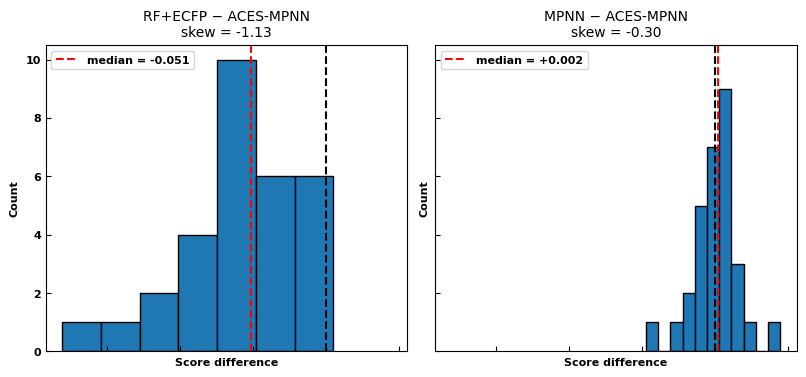

Test MAE


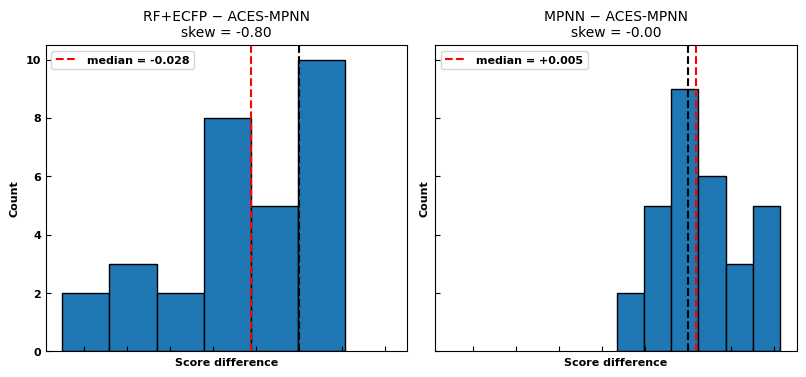

Cliff MAE


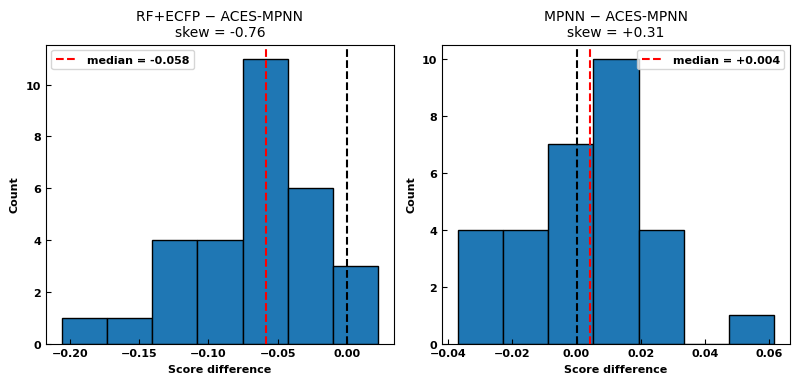

Test RMSE


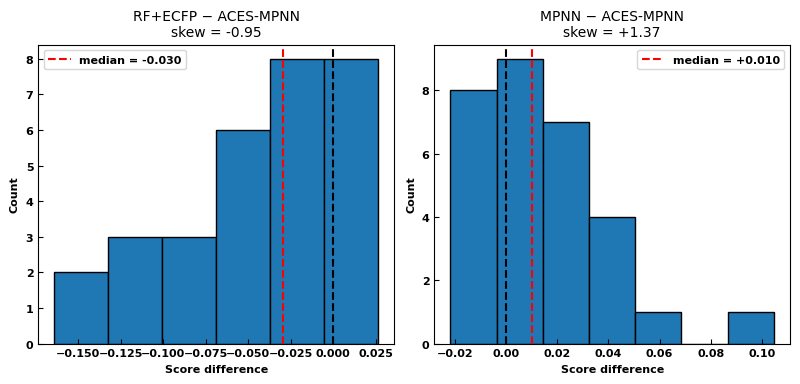

Cliff RMSE


In [17]:
for display_name, actual_metric_name in mae_metrics_config.items():
    current_metric_data = {
        GROUP_RF: get_avg_scores_for_group_metric(df_avg_by_target, 'rf', 'no', actual_metric_name),
        GROUP_NN_NO_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', actual_metric_name),
        GROUP_NN_YES_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'yes', actual_metric_name),
    }
    fig = plot_pairwise_diffs(
    all_scores=current_metric_data,
    baseline_name=GROUP_NN_YES_SUPERVIS,
    n_rows=2,          # customise to taste
    n_cols=3,
    bins="auto",
    sharex=True,
    sharey=True,
    )
    plt.show()
    # save as pdf
    print(display_name)
    fig.savefig(f"images/{display_name}_pairwise_diffs.pdf", bbox_inches="tight")
for display_name, actual_metric_name in rmse_metrics_config.items():
    current_metric_data = {
        GROUP_RF: get_avg_scores_for_group_metric(df_avg_by_target, 'rf', 'no', actual_metric_name),
        GROUP_NN_NO_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'no', actual_metric_name),
        GROUP_NN_YES_SUPERVIS: get_avg_scores_for_group_metric(df_avg_by_target, BACKBONE_GNN, 'yes', actual_metric_name),
    }
    fig = plot_pairwise_diffs(
    all_scores=current_metric_data,
    baseline_name=GROUP_NN_YES_SUPERVIS,
    n_rows=2,          # customise to taste
    n_cols=3,
    bins="auto",
    sharex=False,
    sharey=False,
    )
    plt.show()
    # save as pdf
    print(display_name)
    fig.savefig(f"images/{display_name}_pairwise_diffs.pdf", bbox_inches="tight")

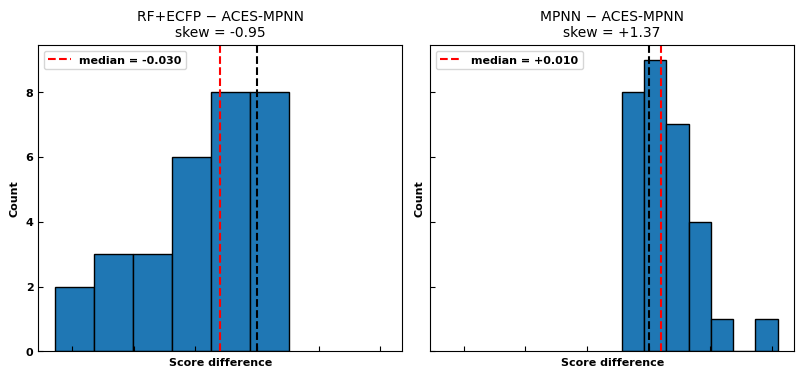

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

def plot_pairwise_diffs(
        all_scores: dict[str, list[float]],
        baseline_name: str,
        n_rows: int = 2,
        n_cols: int = 2,
        bins: str | int = "auto",
        sharex: bool = False,
        sharey: bool = False,
        figsize_per_ax: tuple[float, float] = (4, 3.5),
    ):
    """
    Create a grid of histograms of paired score differences:
    (group – baseline) for every non‑baseline entry in `all_scores`.

    Parameters
    ----------
    all_scores : dict[str, list[float]]
        Mapping group name → list of scores (same length for all keys).
    baseline_name : str
        Key in `all_scores` to use as the paired reference.
    n_rows, n_cols : int
        Grid shape for the subplots.
    bins : "auto" or int
        Histogram bin spec passed to `plt.hist`.
    sharex, sharey : bool
        Share axes among subplots (`matplotlib` style).
    figsize_per_ax : (width, height)
        Size of one subplot; overall figure size scales with rows × cols.

    Returns
    -------
    matplotlib.figure.Figure
        The assembled figure (already tight‑laid‑out).
    """
    baseline = np.asarray(all_scores[baseline_name])
    groups = [g for g in all_scores if g != baseline_name]
    n_plots = len(groups)

    # --- sanity check for grid capacity ------------------------------------
    if n_rows * n_cols < n_plots:
        raise ValueError(
            f"Grid {n_rows}×{n_cols} can display only "
            f"{n_rows*n_cols} plots but {n_plots} are needed."
        )

    # --- prepare figure & axes ---------------------------------------------
    fig_w = figsize_per_ax[0] * n_cols
    fig_h = figsize_per_ax[1] * n_rows
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        sharex=sharex, sharey=sharey
    )
    axes = axes.flatten()  # 1‑D index

    # --- make one histogram per comparison ---------------------------------
    for ax, group in zip(axes, groups):
        diffs = np.asarray(all_scores[group]) - baseline
        ax.hist(diffs, bins=bins, edgecolor="black")
        ax.axvline(0, linestyle="--", color="k")          # no‑change line
        median = np.median(diffs)
        ax.axvline(median, linestyle="--", color="red",
                   label=f"median = {median:+.3f}")
        ax.set_title(
            f"{group} − {baseline_name}\nskew = {skew(diffs, bias=False):+.2f}",
            fontsize=10
        )
        ax.set_xlabel("Score difference")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    # --- drop any unused axes ----------------------------------------------
    for j in range(n_plots, n_rows * n_cols):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig

fig = plot_pairwise_diffs(
    all_scores=current_metric_data,
    baseline_name=GROUP_NN_YES_SUPERVIS,
    n_rows=2,          # customise to taste
    n_cols=3,
    bins="auto",
    sharex=True,
    sharey=True,
)
plt.show()
# save as pdf
fig.savefig("images/attribution_all_methods_comparison_pairwise_diffs.pdf", bbox_inches="tight")



--- 4. Per-Target Paired Wilcoxon Test (Text Summary) ---
         Target    Attribution  N Pairs  Median (Sup)  Median (Unsup)  Statistic  p-value Sig. Diff. (p<0.05)
CHEMBL4616_EC50    gradcam_acc       10        0.8652          0.8421    52.0000   0.0049                 Yes
CHEMBL4616_EC50 smoothgrad_acc       10        0.8014          0.8063    44.0000   0.0527                  No
CHEMBL4616_EC50 inputxgrad_acc       10        0.8392          0.7915    50.0000   0.0098                 Yes
CHEMBL4616_EC50         ig_acc       10        0.8413          0.8118    48.0000   0.0186                 Yes
CHEMBL4616_EC50       mask_acc       10        0.8330          0.8406    27.0000   0.5391                  No
  CHEMBL4792_Ki    gradcam_acc       10        0.8467          0.8124    53.0000   0.0029                 Yes
  CHEMBL4792_Ki smoothgrad_acc       10        0.7650          0.7667    33.0000   0.3125                  No
  CHEMBL4792_Ki inputxgrad_acc       10        0.7912        

Per-target paired plot saved to per_target_paired_attribution_violins_nn.pdf


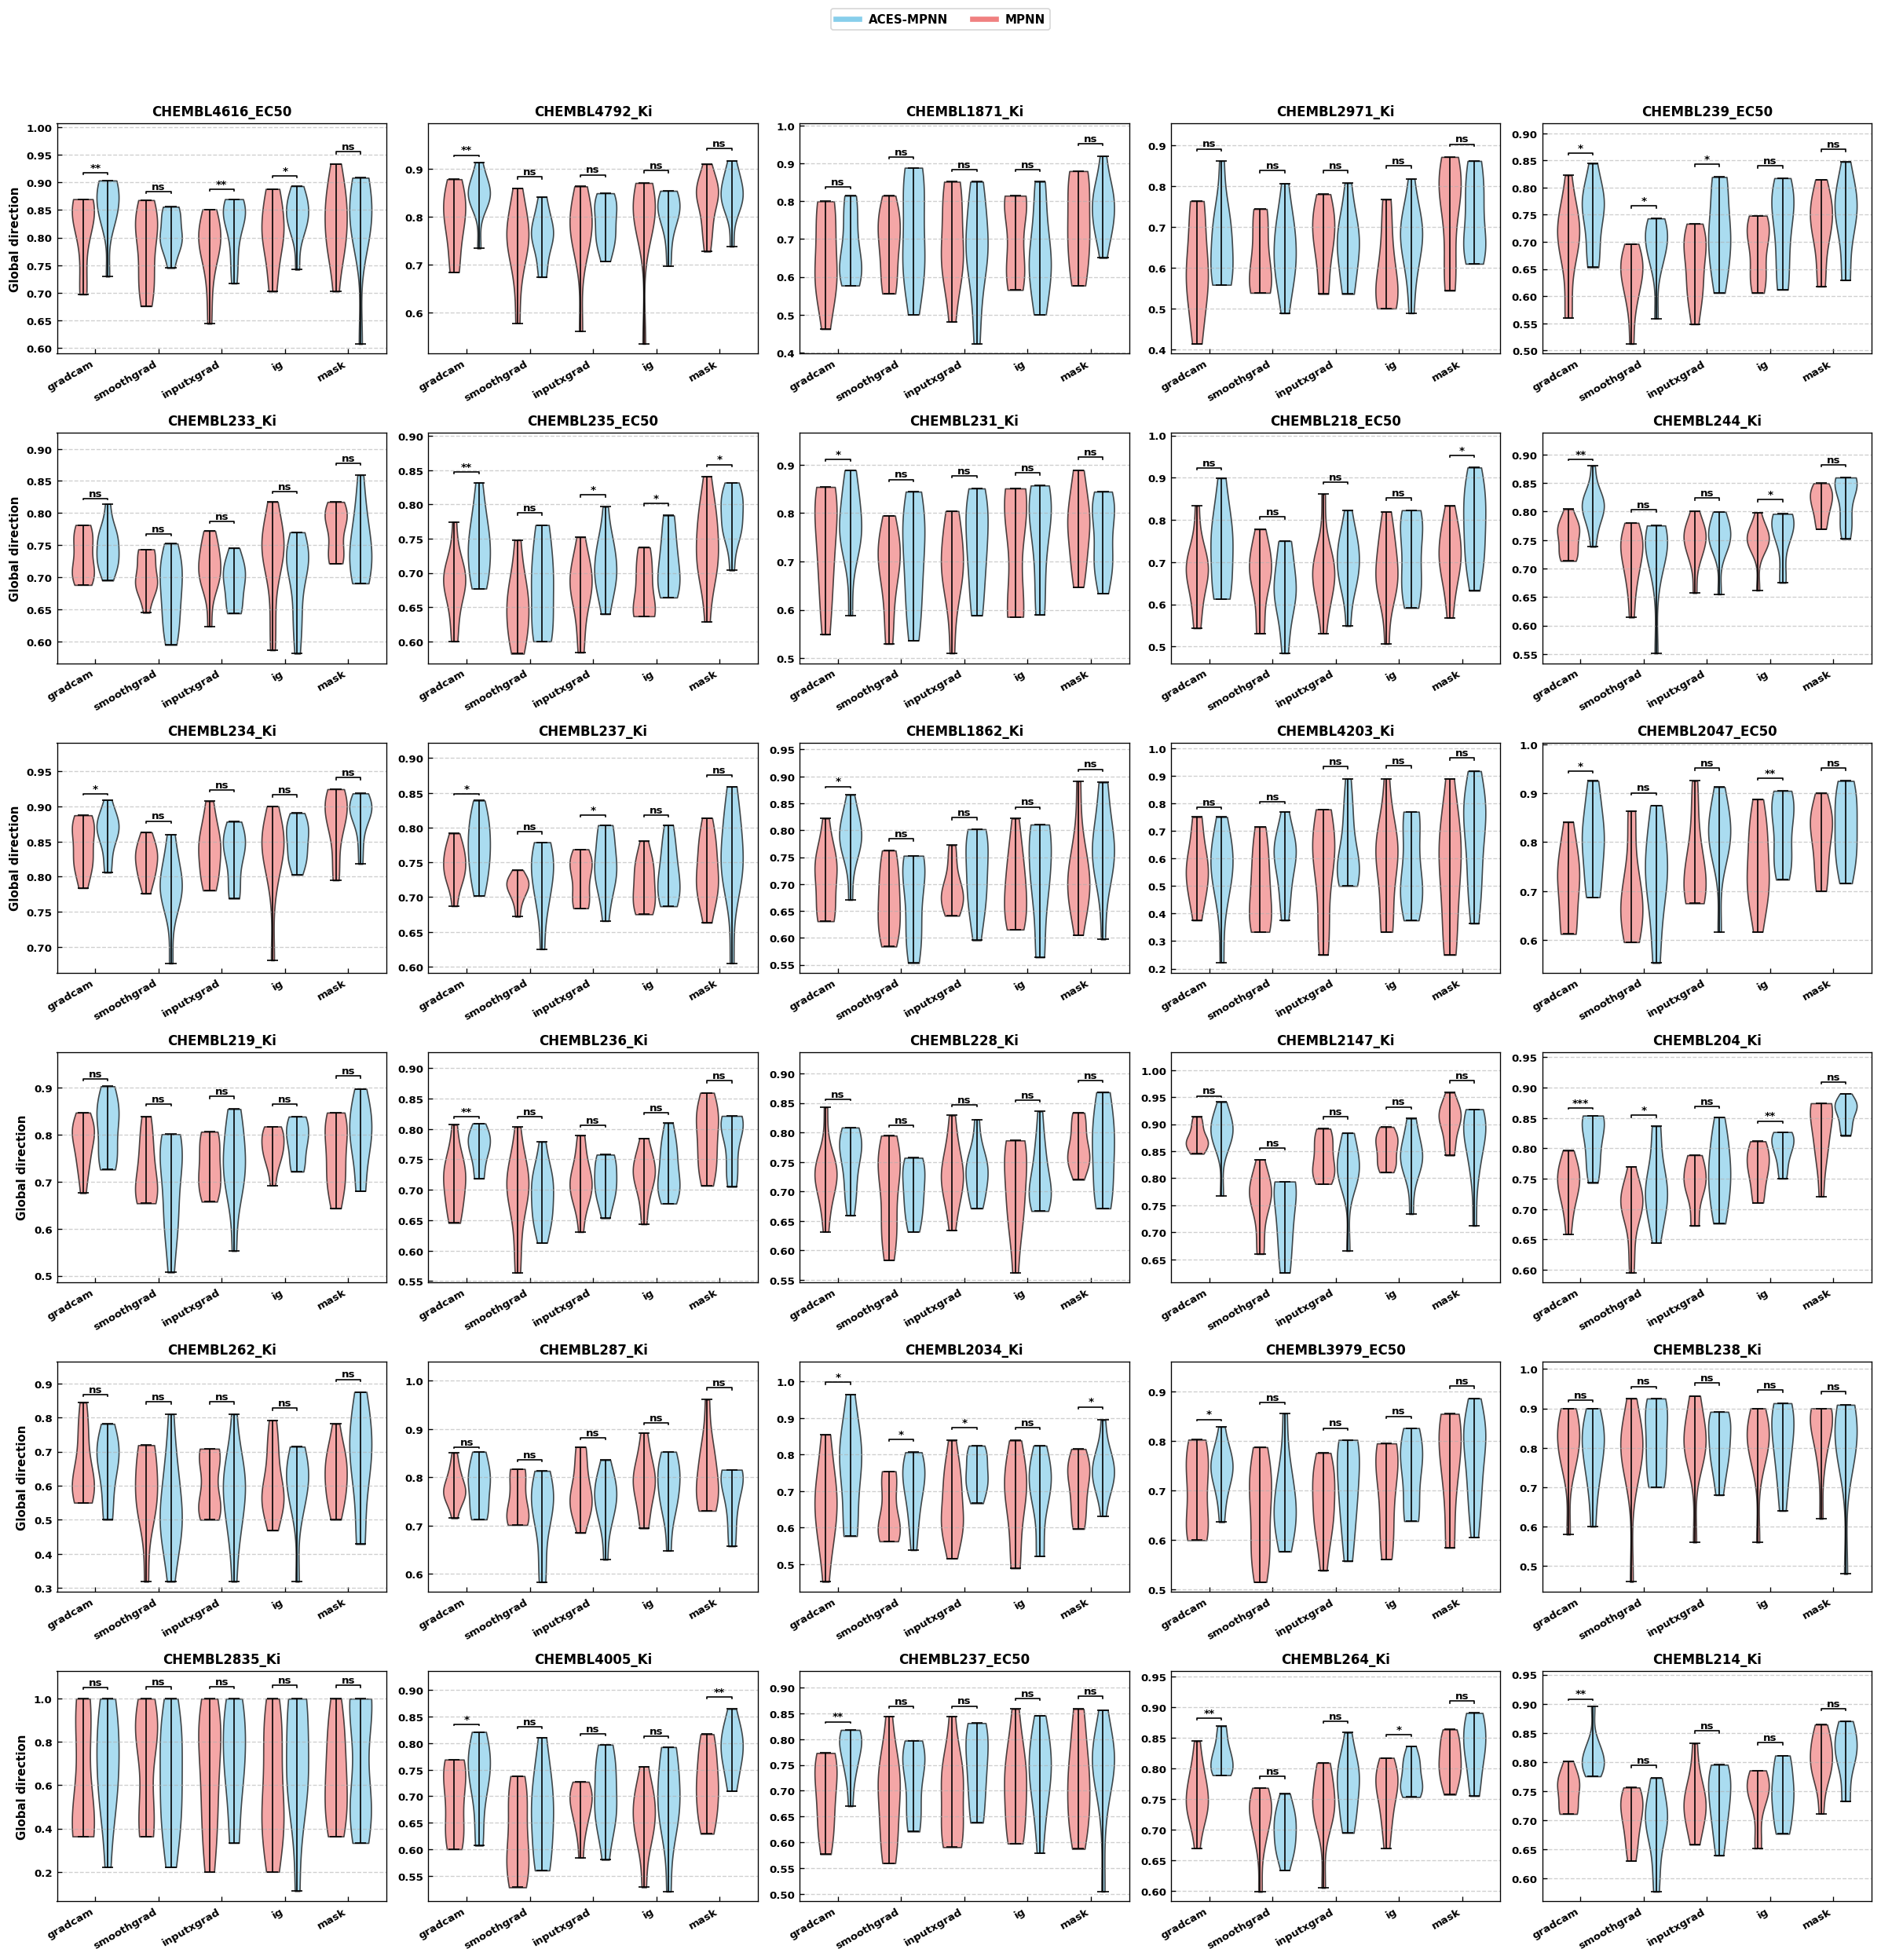


All analyses complete. Check for generated .pdf and any .png files.


In [23]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats # Assuming you have this import

BACKBONE = 'nn'

def collect_data_for_per_target_paired_plots(df, nn_attribution_metrics, alpha=0.05):
    """
    Collects data for per-target paired violin plots, performing Wilcoxon signed-rank tests.
    Uses the original df (not aggregated by target).
    Pairing is done by 'split_seed'.
    """
    if 'target' not in df.columns:
        print("Error: 'target' column not found in DataFrame. Cannot collect per-target paired data.")
        return {}

    collected_data = {}
    unique_targets = df['target'].unique()

    for current_target in unique_targets:
        collected_data[current_target] = {}
        for attr_metric_name in nn_attribution_metrics:
            df_subset = df[
                (df['target'] == current_target) &
                (df['method'] == BACKBONE) &
                (df['metric_name'] == attr_metric_name)
            ]

            if df_subset.empty:
                continue

            scores_yes_series = df_subset[df_subset['x_supervis'] == 'yes'] \
                                .set_index('split_seed')['metric_value']
            scores_no_series = df_subset[df_subset['x_supervis'] == 'no'] \
                               .set_index('split_seed')['metric_value']

            merged_scores_df = pd.merge(
                scores_yes_series.rename('metric_value_yes'),
                scores_no_series.rename('metric_value_no'),
                left_index=True,
                right_index=True,
                how='inner'
            )

            if merged_scores_df.shape[0] < 2: # Need at least 2 pairs for statistical test and meaningful violin
                continue

            paired_scores_yes = merged_scores_df['metric_value_yes'].tolist()
            paired_scores_no = merged_scores_df['metric_value_no'].tolist()

            p_value = 1.0 # Default if test fails or not enough data
            try:
                # HA: median(scores_yes) > median(scores_no) (improvement with supervision)
                # Using Wilcoxon signed-rank test
                stat_test_result = stats.wilcoxon(paired_scores_yes, paired_scores_no, alternative='greater', zero_method='wilcox')
                p_value = stat_test_result.pvalue
            except Exception:
                pass # Keep default p_value if test fails

            collected_data[current_target][attr_metric_name] = {
                'yes_scores': paired_scores_yes,
                'no_scores': paired_scores_no,
                'p_value': p_value
            }
        if not collected_data[current_target]: # If no metrics had data for this target
            del collected_data[current_target]
            
    return collected_data

# --- NEW: Plotting function for per-target paired violins ---
def plot_per_target_paired_violins(
    data_for_plotting: dict, # {target: {attr_method: {yes_scores, no_scores, p_value}}}
    all_nn_attribution_metrics: list, # To determine order and all possible methods for x-axis
    alpha_levels=(0.05, 0.01, 0.001, 0.0001), # Standard significance levels
    figsize_per_subplot=(4, 3.5),
    save_path: str | None = None,
    plot_title_prefix: str = f""
):
    """
    Generates subplots for each target, showing paired violins (supervised vs. unsupervised)
    for each NN attribution method.
    """
    targets_with_data = list(data_for_plotting.keys())
    if not targets_with_data:
        print("No data available for per-target paired violin plots.")
        return

    num_targets = len(targets_with_data)
    # Determine grid size for subplots
    cols = 5 if num_targets > 2 else num_targets 
    rows = math.ceil(num_targets / cols)

    fig, axes = plt.subplots(rows, cols, 
                             figsize=(cols * figsize_per_subplot[0], rows * figsize_per_subplot[1]),
                             squeeze=False, dpi=120) # squeeze=False ensures axes is always 2D
    axes = axes.flatten() # Flatten to 1D array for easy iteration

    colors = {'yes': 'skyblue', 'no': 'lightcoral'}
    legend_handles = [
        plt.Line2D([0], [0], color=colors['yes'], lw=4, label='ACES-MPNN'),
        plt.Line2D([0], [0], color=colors['no'], lw=4, label='MPNN')
    ]

    for i, target_name in enumerate(targets_with_data):
        ax = axes[i]
        target_data = data_for_plotting[target_name]
        
        # Filter nn_attribution_metrics to only those present in target_data for consistent x-axis
        plot_methods = [m for m in all_nn_attribution_metrics if m in target_data]
        if not plot_methods:
            ax.text(0.5, 0.5, "No data for this target", ha='center', va='center')
            ax.set_title(f"{target_name}", fontsize=10, fontweight='bold')
            ax.axis('off')
            continue

        x_positions = np.arange(len(plot_methods)) # Base positions for each attribution method
        violin_width = 0.35
        max_y_val_subplot = -float('inf')

        for j, attr_method in enumerate(plot_methods):
            method_data = target_data[attr_method]
            yes_scores = method_data['yes_scores']
            no_scores = method_data['no_scores']
            p_val = method_data['p_value']

            if yes_scores: max_y_val_subplot = max(max_y_val_subplot, np.max(yes_scores))
            if no_scores: max_y_val_subplot = max(max_y_val_subplot, np.max(no_scores))

            # Plot 'no supervision' violin
            pos_no = x_positions[j] - violin_width/2 - 0.02
            parts_no = ax.violinplot(no_scores, positions=[pos_no], widths=violin_width,
                                     showmeans=False, showmedians=False, showextrema=True)
            for pc in parts_no['bodies']:
                pc.set_facecolor(colors['no'])
                pc.set_edgecolor('black')
                pc.set_alpha(0.7)
            for partname in ('cbars', 'cmins', 'cmaxes'):
                vp = parts_no[partname]
                vp.set_edgecolor('black')
                vp.set_linewidth(1)

            # Plot 'yes supervision' violin
            pos_yes = x_positions[j] + violin_width/2 + 0.02
            parts_yes = ax.violinplot(yes_scores, positions=[pos_yes], widths=violin_width,
                                      showmeans=False, showmedians=False, showextrema=True)
            for pc in parts_yes['bodies']:
                pc.set_facecolor(colors['yes'])
                pc.set_edgecolor('black')
                pc.set_alpha(0.7)
            for partname in ('cbars', 'cmins', 'cmaxes'):
                vp = parts_yes[partname]
                vp.set_edgecolor('black')
                vp.set_linewidth(1)

            # Annotation for significance
            stars = "ns"
            # alpha_levels are typically (0.05, 0.01, 0.001, 0.0001)
            # We check from most stringent (smallest p-value) to least stringent.
            num_alpha_lvls = len(alpha_levels)
            for k in range(num_alpha_lvls):
                # alpha_levels is sorted from largest p-value (least significant) to smallest (most significant)
                # So, alpha_levels[0] is 0.05, alpha_levels[1] is 0.01, etc.
                # We want to assign stars based on the most stringent criterion met.
                # Example: if p_val <= 0.0001 (alpha_levels[3]), assign "****"
                # if p_val <= 0.001 (alpha_levels[2]) but > 0.0001, assign "***"
                
                # Iterate from the most stringent alpha (smallest value)
                alpha_to_check = alpha_levels[num_alpha_lvls - 1 - k] # e.g., 0.0001, then 0.001, ...
                num_stars_to_assign = num_alpha_lvls - k # e.g., 4 stars, then 3 stars, ...
                
                if p_val <= alpha_to_check:
                    stars = "*" * num_stars_to_assign
                    break # Found the most significant level p_val passes
            
            # Determine y for annotation
            y_max_pair = -float('inf')
            if yes_scores: y_max_pair = max(y_max_pair, np.max(yes_scores))
            if no_scores: y_max_pair = max(y_max_pair, np.max(no_scores))
            
            current_ylim = ax.get_ylim()
            plot_height = current_ylim[1] - current_ylim[0]
            if plot_height <= 0 : plot_height = 1 # Avoid division by zero if ylim not set
            
            y_offset_factor = 0.05 * plot_height if y_max_pair > -float('inf') else 0.05
            annotation_y = (y_max_pair if y_max_pair > -float('inf') else current_ylim[1]*0.8) + y_offset_factor
            
            ax.plot([pos_no, pos_no, pos_yes, pos_yes], 
                    [annotation_y, annotation_y + y_offset_factor*0.2, 
                     annotation_y + y_offset_factor*0.2, annotation_y], 
                    lw=1.0, c='black')
            ax.text((pos_no + pos_yes) / 2, annotation_y + y_offset_factor*0.2, stars, 
                    ha='center', va='bottom', color='black', fontsize=8)
            max_y_val_subplot = max(max_y_val_subplot, annotation_y + y_offset_factor*0.4)


        ax.set_xticks(x_positions)
        ax.set_xticklabels([m.replace('_acc', '') for m in plot_methods], rotation=30, ha="right", fontsize=8)
        ax.set_title(f"{target_name}", fontsize=10, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        if i % cols == 0: # Only Y label for the first column
             ax.set_ylabel("Global direction", fontsize=9)
        
        if max_y_val_subplot > -float('inf'):
            current_ymin_sub, _ = ax.get_ylim()
            ax.set_ylim(current_ymin_sub, max_y_val_subplot * 1.05)


    # Hide any unused subplots
    for j in range(num_targets, rows * cols):
        axes[j].axis('off')

    fig.legend(handles=legend_handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.99), fontsize=9)
    fig.suptitle(plot_title_prefix, fontsize=16, fontweight='bold', y=1.03) # Adjust y for suptitle
    
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # rect to make space for suptitle and legend
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Per-target paired plot saved to {save_path}")
    plt.show()

# --- 4. Per-Dataset Paired t-test for Attribution Method Improvement (Supervision vs. No Supervision) - TEXT SUMMARY ---
# (Code as previously provided by user, using 'target' instead of 'dataset' for consistency)
# This section already uses Wilcoxon, so it's consistent with the plotting data collection.
print("\n--- 4. Per-Target Paired Wilcoxon Test (Text Summary) ---") # Updated title
nn_attribution_metrics_for_test = [ # Renamed to avoid conflict
    'gradcam_acc', 'smoothgrad_acc', 'inputxgrad_acc', 'ig_acc', 'mask_acc'
]
if 'target' not in df.columns:
    print("Error: 'target' column not found. Cannot perform per-target Wilcoxon tests.")
else:
    unique_targets_for_test = df['target'].unique()
    alpha_ttest = 0.05 # This alpha is for the text summary's significance check
    results_summary_ttest = []
    for current_target_ttest in unique_targets_for_test:
        dataset_has_results_ttest = False
        for attr_metric_name_ttest in nn_attribution_metrics_for_test:
            df_subset_ttest = df[
                (df['target'] == current_target_ttest) & (df['method'] == BACKBONE) &
                (df['metric_name'] == attr_metric_name_ttest)
            ]
            if df_subset_ttest.empty: continue
            scores_yes_series_ttest = df_subset_ttest[df_subset_ttest['x_supervis'] == 'yes'].set_index('split_seed')['metric_value']
            scores_no_series_ttest = df_subset_ttest[df_subset_ttest['x_supervis'] == 'no'].set_index('split_seed')['metric_value']
            merged_scores_df_ttest = pd.merge(
                scores_yes_series_ttest.rename('yes'), scores_no_series_ttest.rename('no'),
                left_index=True, right_index=True, how='inner'
            )
            if merged_scores_df_ttest.shape[0] < 2: continue
            scores_with_ttest = merged_scores_df_ttest['yes']
            scores_without_ttest = merged_scores_df_ttest['no']
            try:
                # Using Wilcoxon test, alternative="two-sided" for this summary as per original code
                # If you want one-sided for summary too, change alternative to 'greater'
                wilcoxon_res = stats.wilcoxon(scores_with_ttest, scores_without_ttest, alternative="greater", zero_method='wilcox')
                sig_imp = "Yes" if wilcoxon_res.pvalue < alpha_ttest else "No"
                dataset_has_results_ttest = True
                results_summary_ttest.append({
                    "Target": current_target_ttest, "Attribution": attr_metric_name_ttest,
                    "N Pairs": len(scores_with_ttest), "Median (Sup)": scores_with_ttest.median(), # Changed to Median
                    "Median (Unsup)": scores_without_ttest.median(), # Changed to Median
                    "Statistic": wilcoxon_res.statistic, # Wilcoxon statistic
                    "p-value": wilcoxon_res.pvalue, f"Sig. Diff. (p<{alpha_ttest})": sig_imp # Changed label
                })
            except Exception as e:
                # print(f"Could not perform Wilcoxon test for {current_target_ttest}, {attr_metric_name_ttest}: {e}")
                pass
    if results_summary_ttest:
        summary_df_ttest = pd.DataFrame(results_summary_ttest)
        pd.options.display.float_format = '{:.4f}'.format
        print(summary_df_ttest.to_string(index=False))
        pd.reset_option('display.float_format')
    else: print("No per-target paired Wilcoxon tests could be performed for text summary.")


# --- 5. Per-Target Paired Violin Plots for NN Attribution Method Improvement ---
print("\n--- 5. Per-Target Paired Violin Plots (Supervision vs. No Supervision) ---")
# Use the same list of NN attribution metrics as for the test summary
# nn_attribution_metrics_for_test is already defined

# Collect data for these plots using the new helper function
per_target_plot_data = collect_data_for_per_target_paired_plots(df, nn_attribution_metrics_for_test, alpha=0.05) # alpha here is for the plot's p-value calculation

if per_target_plot_data:
    plot_per_target_paired_violins(
        data_for_plotting=per_target_plot_data,
        all_nn_attribution_metrics=nn_attribution_metrics_for_test, # Pass the full list for consistent x-axis consideration
        alpha_levels=(0.05, 0.01, 0.001, 0.0001), # For star annotation in plots
        save_path=f"per_target_paired_attribution_violins_{BACKBONE}.pdf"
    )
else:
    print("No data collected to generate per-target paired violin plots.")

print("\nAll analyses complete. Check for generated .pdf and any .png files.")


--- 6. Per-Target Paired Violin Plots for nn Value Metrics (RMSE, MAE) ---


Per-target NN value metrics plot saved to per_target_paired_nn_value_metrics.png


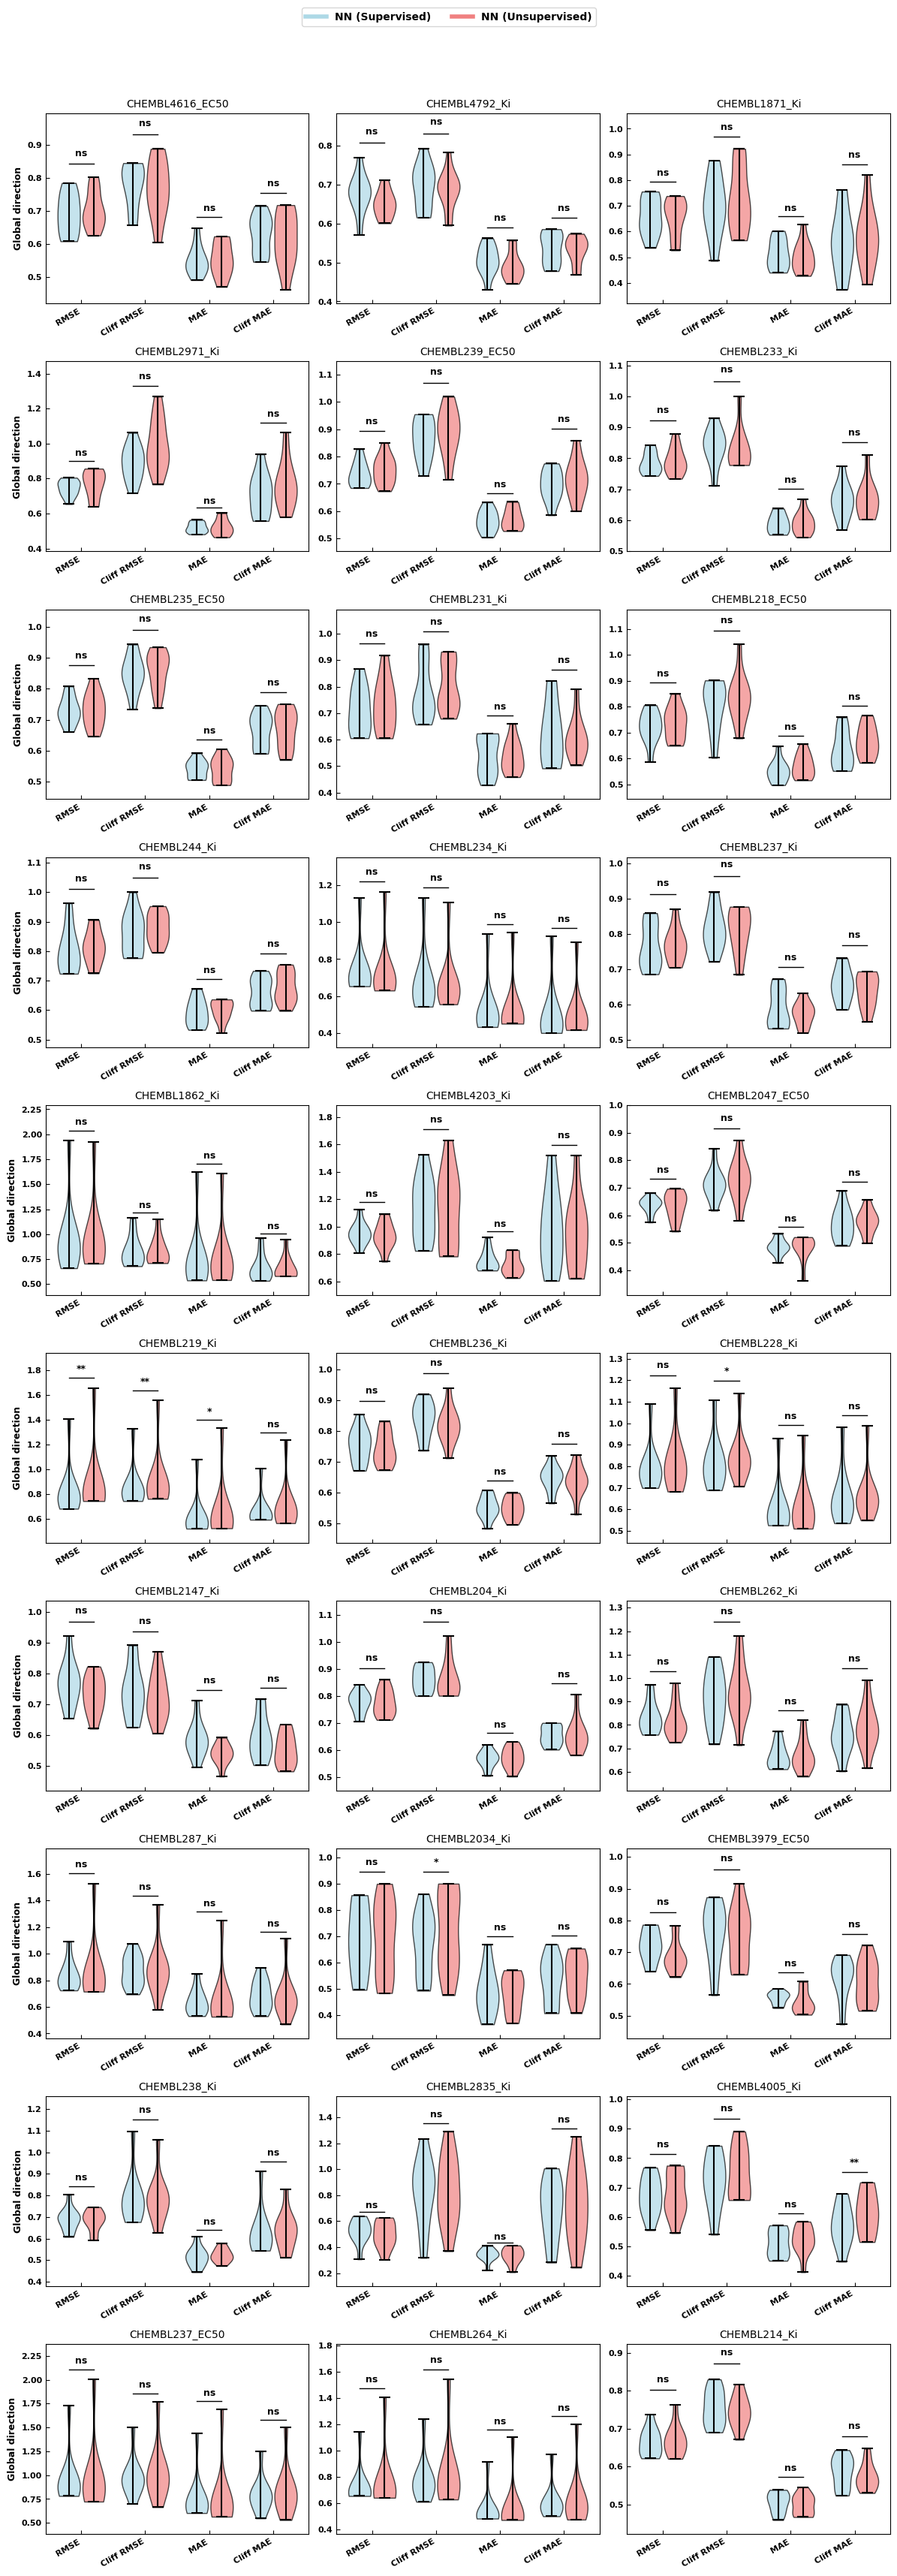


--- 7. Per-Target Paired Wilcoxon Test for nn Value Metrics (Text Summary) ---
         Target     Metric  N Pairs  Mean (NN Sup)  Mean (NN Unsup)  p-value (Wilcoxon, Sup < Unsup) NN Sup Better (p<0.05)
  CHEMBL1862_Ki  Cliff MAE       10         0.6643           0.6676                           0.5000                     No
  CHEMBL1862_Ki Cliff RMSE       10         0.8344           0.8342                           0.6152                     No
  CHEMBL1862_Ki        MAE       10         0.7543           0.7689                           0.3477                     No
  CHEMBL1862_Ki       RMSE       10         0.9643           0.9671                           0.5391                     No
  CHEMBL1871_Ki  Cliff MAE       10         0.5614           0.5786                           0.1875                     No
  CHEMBL1871_Ki Cliff RMSE       10         0.6979           0.7265                           0.0527                     No
  CHEMBL1871_Ki        MAE       10         0.5132  

In [101]:
# --- NEW SECTION 6: Per-Target Paired Analysis for BACKBONE Value Metrics (RMSE, MAE) ---
BACKBONE = 'nn'
# --- Helper function to collect data for per-target paired NN value metrics ---
def collect_data_for_per_target_paired_nn_value_metrics(
    original_df: pd.DataFrame,
    value_metric_names: list # e.g., ['test_rmse', 'test_mae']
):
    """
    Collects data for per-target paired comparisons of NN with supervision vs. without supervision
    for specified value-based metrics (e.g., RMSE, MAE where lower is better).
    Uses Wilcoxon signed-rank test.
    """
    if 'target' not in original_df.columns:
        print("Error: 'target' column not found. Cannot perform per-target analysis for value metrics.")
        return {}
    if not value_metric_names:
        print("No value metric names provided for per-target paired analysis.")
        return {}

    unique_targets = original_df['target'].unique()
    plot_data_collected = {}

    for current_target in unique_targets:
        target_data = {}
        has_data_for_this_target = False
        for val_metric_name in value_metric_names:
            # Filter for NN method and the specific value metric
            df_subset_metric = original_df[
                (original_df['target'] == current_target) &
                (original_df['method'] == 'nn') &
                (original_df['metric_name'] == val_metric_name)
            ]

            if df_subset_metric.empty:
                continue

            scores_yes_series = df_subset_metric[df_subset_metric['x_supervis'] == 'yes'] \
                                .set_index('split_seed')['metric_value']
            scores_no_series = df_subset_metric[df_subset_metric['x_supervis'] == 'no'] \
                               .set_index('split_seed')['metric_value']

            merged_scores_df = pd.merge(
                scores_yes_series.rename('metric_value_yes'),
                scores_no_series.rename('metric_value_no'),
                left_index=True,
                right_index=True,
                how='inner'
            )

            if merged_scores_df.shape[0] < 5: # Min pairs for robust Wilcoxon
                continue

            paired_scores_yes = merged_scores_df['metric_value_yes'].tolist()
            paired_scores_no = merged_scores_df['metric_value_no'].tolist()

            p_val = None
            try:
                # Wilcoxon test: alternative='less' because lower is better for these metrics,
                # testing if 'yes' supervision scores are significantly less than 'no' supervision.
                wilcoxon_result = stats.wilcoxon(paired_scores_yes, paired_scores_no, alternative='less', zero_method='pratt')
                p_val = wilcoxon_result.pvalue
                has_data_for_this_target = True
            except ValueError:
                pass # p_val remains None

            target_data[val_metric_name] = {
                'yes_scores': paired_scores_yes,
                'no_scores': paired_scores_no,
                'p_value': p_val
            }
        
        if has_data_for_this_target and target_data:
            plot_data_collected[current_target] = target_data
            
    return plot_data_collected

# --- Helper function to plot per-target paired BACKBONE value metrics violins ---
def plot_per_target_paired_nn_value_metrics_violins(
    data_for_plotting: dict,
    all_value_metric_names: list, # For x-axis, e.g., ['test_rmse', 'test_cliff_rmse', ...]
    value_metric_display_names: dict, # For prettier x-axis labels, e.g., {'test_rmse': 'RMSE'}
    alpha_levels=(0.05, 0.01, 0.001, 0.0001),
    figsize_per_subplot=(4, 3.5), # Adjusted for potentially fewer x-axis items
    save_path: str | None = None,
    overall_plot_title: str = ""
):
    """
    Plots per-target paired violins for NN value metrics (supervised vs. unsupervised).
    """
    if not data_for_plotting:
        print("No data provided for plotting per-target NN value metrics.")
        return

    targets = list(data_for_plotting.keys())
    num_targets = len(targets)
    if num_targets == 0:
        print("No targets with data to plot for NN value metrics.")
        return

    # Determine grid size for subplots
    cols = 3 # Fixed number of columns for subplots
    rows = math.ceil(num_targets / cols)
    
    fig_height = rows * figsize_per_subplot[1]
    fig_width = cols * figsize_per_subplot[0]
    
    # Increase figure width slightly if few columns to avoid crowding if metric names are long
    if cols < 3 and len(all_value_metric_names) > 2:
        fig_width = max(fig_width, len(all_value_metric_names) * 2.5 * cols)


    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), squeeze=False, sharey=False) # Not sharing Y for value metrics
    axes = axes.flatten() # Flatten to 1D array for easy iteration

    min_y_overall = float('inf')
    max_y_overall = float('-inf')
    
    # First pass to find overall y-limits if sharey=True were used, or for individual limits
    for target_name, target_metrics_data in data_for_plotting.items():
        for metric_name_internal in all_value_metric_names:
            metric_data = target_metrics_data.get(metric_name_internal)
            if metric_data and metric_data['yes_scores'] and metric_data['no_scores']:
                min_y_overall = min(min_y_overall, min(metric_data['yes_scores']), min(metric_data['no_scores']))
                max_y_overall = max(max_y_overall, max(metric_data['yes_scores']), max(metric_data['no_scores']))

    if min_y_overall == float('inf'): # No data found at all
        min_y_overall = 0
        max_y_overall = 1


    for i, target_name in enumerate(targets):
        ax = axes[i]
        target_metrics_data = data_for_plotting[target_name]
        
        x_positions = np.arange(len(all_value_metric_names))
        violin_width = 0.35
        
        current_min_y_subplot = float('inf')
        current_max_y_subplot = float('-inf')

        for j, metric_name_internal in enumerate(all_value_metric_names):
            metric_data = target_metrics_data.get(metric_name_internal)
            
            if metric_data and metric_data['yes_scores'] and metric_data['no_scores']:
                scores_yes_val = metric_data['yes_scores']
                scores_no_val = metric_data['no_scores']
                p_val_metric = metric_data['p_value']

                # Update subplot y-limits
                current_min_y_subplot = min(current_min_y_subplot, min(scores_yes_val), min(scores_no_val))
                current_max_y_subplot = max(current_max_y_subplot, max(scores_yes_val), max(scores_no_val))

                # Plot violins
                parts_yes = ax.violinplot(scores_yes_val, positions=[x_positions[j] - violin_width/2 - 0.02], widths=violin_width, showextrema=True, showmedians=False)
                parts_no = ax.violinplot(scores_no_val, positions=[x_positions[j] + violin_width/2 + 0.02], widths=violin_width, showextrema=True, showmedians=False)

                for pc in parts_yes['bodies']: pc.set_facecolor('lightblue'); pc.set_edgecolor('black'); pc.set_alpha(0.7)
                for partname in ('cbars', 'cmins', 'cmaxes'): parts_yes[partname].set_edgecolor('black')
                
                for pc in parts_no['bodies']: pc.set_facecolor('lightcoral'); pc.set_edgecolor('black'); pc.set_alpha(0.7)
                for partname in ('cbars', 'cmins', 'cmaxes'): parts_no[partname].set_edgecolor('black')

                # Significance annotation
                if p_val_metric is not None:
                    stars = "ns"
                    if p_val_metric <= alpha_levels[3]: stars = "****"
                    elif p_val_metric <= alpha_levels[2]: stars = "***"
                    elif p_val_metric <= alpha_levels[1]: stars = "**"
                    elif p_val_metric <= alpha_levels[0]: stars = "*"
                    
                    y_max_violins = max(max(scores_yes_val), max(scores_no_val))
                    ax.plot([x_positions[j] - violin_width/2 -0.02, x_positions[j] + violin_width/2+0.02], [y_max_violins * 1.05, y_max_violins * 1.05], lw=1, c='black')
                    ax.text(x_positions[j], y_max_violins * 1.07, stars, ha='center', va='bottom', fontsize=9)
            else:
                # Placeholder if no data for this metric in this target
                ax.text(x_positions[j], (min_y_overall + max_y_overall) / 2 if min_y_overall != float('inf') else 0.5, "N/A", ha='center', va='center', fontsize=8, color='grey')


        ax.set_xticks(x_positions)
        ax.set_xticklabels([value_metric_display_names.get(m, m) for m in all_value_metric_names], rotation=30, ha="right", fontsize=8)
        ax.set_title(target_name, fontsize=10)
        if i % cols == 0: # Only show y-label for the first plot in each row
            ax.set_ylabel("Global direction", fontsize=9)
        
        # Set y-limits for the current subplot
        if current_min_y_subplot != float('inf'):
             y_range = current_max_y_subplot - current_min_y_subplot
             ax.set_ylim(current_min_y_subplot - y_range * 0.1, current_max_y_subplot + y_range * 0.25) # Extra space for stars
        else: # Fallback if no data in subplot
            ax.set_ylim(min_y_overall - (max_y_overall-min_y_overall)*0.1 if min_y_overall != float('inf') else 0, 
                        max_y_overall + (max_y_overall-min_y_overall)*0.25 if max_y_overall != float('-inf') else 1)


    # Create a single legend for the entire figure
    handles = [plt.Line2D([0], [0], color='lightblue', lw=4, label='NN (Supervised)'),
               plt.Line2D([0], [0], color='lightcoral', lw=4, label='NN (Unsupervised)')]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.98 if rows > 1 else 1.06 - (0.02 * rows) ), ncol=2, fontsize=10) # Adjust legend position

    fig.suptitle(overall_plot_title, fontsize=14, y=0.995 if rows > 1 else 1.08 - (0.03 * rows))
    
    plt.tight_layout(rect=[0, 0, 1, 0.95 if rows > 1 else 0.92]) # Adjust rect to make space for suptitle and legend

    # Hide any unused subplots
    for j in range(num_targets, rows * cols):
        fig.delaxes(axes[j])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Per-target NN value metrics plot saved to {save_path}")
    plt.show()


# --- Call the new functions for BACKBONE Value Metrics ---
print(f"\n--- 6. Per-Target Paired Violin Plots for {BACKBONE} Value Metrics (RMSE, MAE) ---")

nn_value_metrics_to_analyze = ['test_rmse', 'test_cliff_rmse', 'test_mae', 'test_cliff_mae']
nn_value_metric_display_names = {
    'test_rmse': 'RMSE',
    'test_cliff_rmse': 'Cliff RMSE',
    'test_mae': 'MAE',
    'test_cliff_mae': 'Cliff MAE'
}

per_target_nn_value_data = collect_data_for_per_target_paired_nn_value_metrics(
    df, 
    nn_value_metrics_to_analyze
)

if per_target_nn_value_data:
    plot_per_target_paired_nn_value_metrics_violins(
        data_for_plotting=per_target_nn_value_data,
        all_value_metric_names=nn_value_metrics_to_analyze,
        value_metric_display_names=nn_value_metric_display_names,
        save_path="per_target_paired_nn_value_metrics.png"
    )
else:
    print(f"No data collected to generate per-target paired {BACKBONE} value metrics plots.")


# --- NEW SECTION 7: Per-Target Paired Wilcoxon Test for BACKBONE Value Metrics (Text Summary) ---
print(f"\n--- 7. Per-Target Paired Wilcoxon Test for {BACKBONE} Value Metrics (Text Summary) ---")

if 'target' not in df.columns:
    print("Error: 'target' column not found. Cannot perform per-target Wilcoxon tests for value metrics.")
else:
    alpha_val_test = 0.05
    results_summary_value_metrics = []
    
    # Use the data already collected for plotting if available, or re-collect if necessary
    # For simplicity here, we'll use the already collected data if it exists.
    # Otherwise, one might call collect_data_for_per_target_paired_nn_value_metrics again
    # or integrate summary generation into the collection function.

    if per_target_nn_value_data: # Reuse collected data
        for target_name, metrics_data in per_target_nn_value_data.items():
            for metric_name, data_dict in metrics_data.items():
                if data_dict['p_value'] is not None: # Test was successful
                    scores_yes = data_dict['yes_scores']
                    scores_no = data_dict['no_scores']
                    p_value = data_dict['p_value']
                    
                    sig_imp = "Yes" if p_value < alpha_val_test else "No"
                    
                    results_summary_value_metrics.append({
                        "Target": target_name,
                        "Metric": nn_value_metric_display_names.get(metric_name, metric_name),
                        "N Pairs": len(scores_yes),
                        "Mean (NN Sup)": np.mean(scores_yes),
                        "Mean (NN Unsup)": np.mean(scores_no),
                        "p-value (Wilcoxon, Sup < Unsup)": p_value,
                        f"NN Sup Better (p<{alpha_val_test})": sig_imp
                    })
    else:
        # Fallback: Re-calculate if per_target_nn_value_data wasn't populated (e.g., if plotting was skipped)
        # This part is a bit redundant if plotting already happened.
        # Consider integrating summary into the collection function or ensuring collection always runs.
        print("Plot data not available for summary, attempting to re-evaluate for text summary...")
        unique_targets_val_test = df['target'].unique()
        for current_target_val_test in unique_targets_val_test:
            for val_metric_name_test in nn_value_metrics_to_analyze:
                df_subset_val_test = df[
                    (df['target'] == current_target_val_test) &
                    (df['method'] == BACKBONE) &
                    (df['metric_name'] == val_metric_name_test)
                ]
                if df_subset_val_test.empty: continue
                
                scores_yes_series_vt = df_subset_val_test[df_subset_val_test['x_supervis'] == 'yes'].set_index('split_seed')['metric_value']
                scores_no_series_vt = df_subset_val_test[df_subset_val_test['x_supervis'] == 'no'].set_index('split_seed')['metric_value']
                merged_scores_df_vt = pd.merge(
                    scores_yes_series_vt.rename('yes'), scores_no_series_vt.rename('no'),
                    left_index=True, right_index=True, how='inner'
                )
                if merged_scores_df_vt.shape[0] < 5: continue

                scores_with_supervision_vt = merged_scores_df_vt['yes']
                scores_without_supervision_vt = merged_scores_df_vt['no']
                
                try:
                    test_res_vt = stats.wilcoxon(scores_with_supervision_vt, scores_without_supervision_vt, alternative='less', zero_method='pratt')
                    p_value_res_vt = test_res_vt.pvalue
                    sig_imp_vt = "Yes" if p_value_res_vt is not None and p_value_res_vt < alpha_val_test else "No"
                    
                    results_summary_value_metrics.append({
                        "Target": current_target_val_test,
                        "Metric": nn_value_metric_display_names.get(val_metric_name_test, val_metric_name_test),
                        "N Pairs": len(scores_with_supervision_vt),
                        "Mean (NN Sup)": scores_with_supervision_vt.mean(),
                        "Mean (NN Unsup)": scores_without_supervision_vt.mean(),
                        "p-value (Wilcoxon, Sup < Unsup)": p_value_res_vt,
                        f"NN Sup Better (p<{alpha_val_test})": sig_imp_vt
                    })
                except ValueError: pass # Wilcoxon test failed
                except Exception: pass # Other errors

    if results_summary_value_metrics:
        summary_df_value_metrics = pd.DataFrame(results_summary_value_metrics)
        pd.options.display.float_format = '{:.4f}'.format
        print(summary_df_value_metrics.sort_values(by=["Target", "Metric"]).to_string(index=False))
        pd.reset_option('display.float_format')
    else:
        print(f"No per-target paired Wilcoxon tests could be performed for {BACKBONE} value metrics (or all had insufficient pairs).")


print("\nAll analyses complete. Check for generated .png files.")




--- Analyzing Value Metrics for Backbone: nn ---

--- 6. Per-Target Paired Violin Plots for nn Value Metrics ---
Per-target nn value metrics plot saved to per_target_paired_nn_value_metrics.png


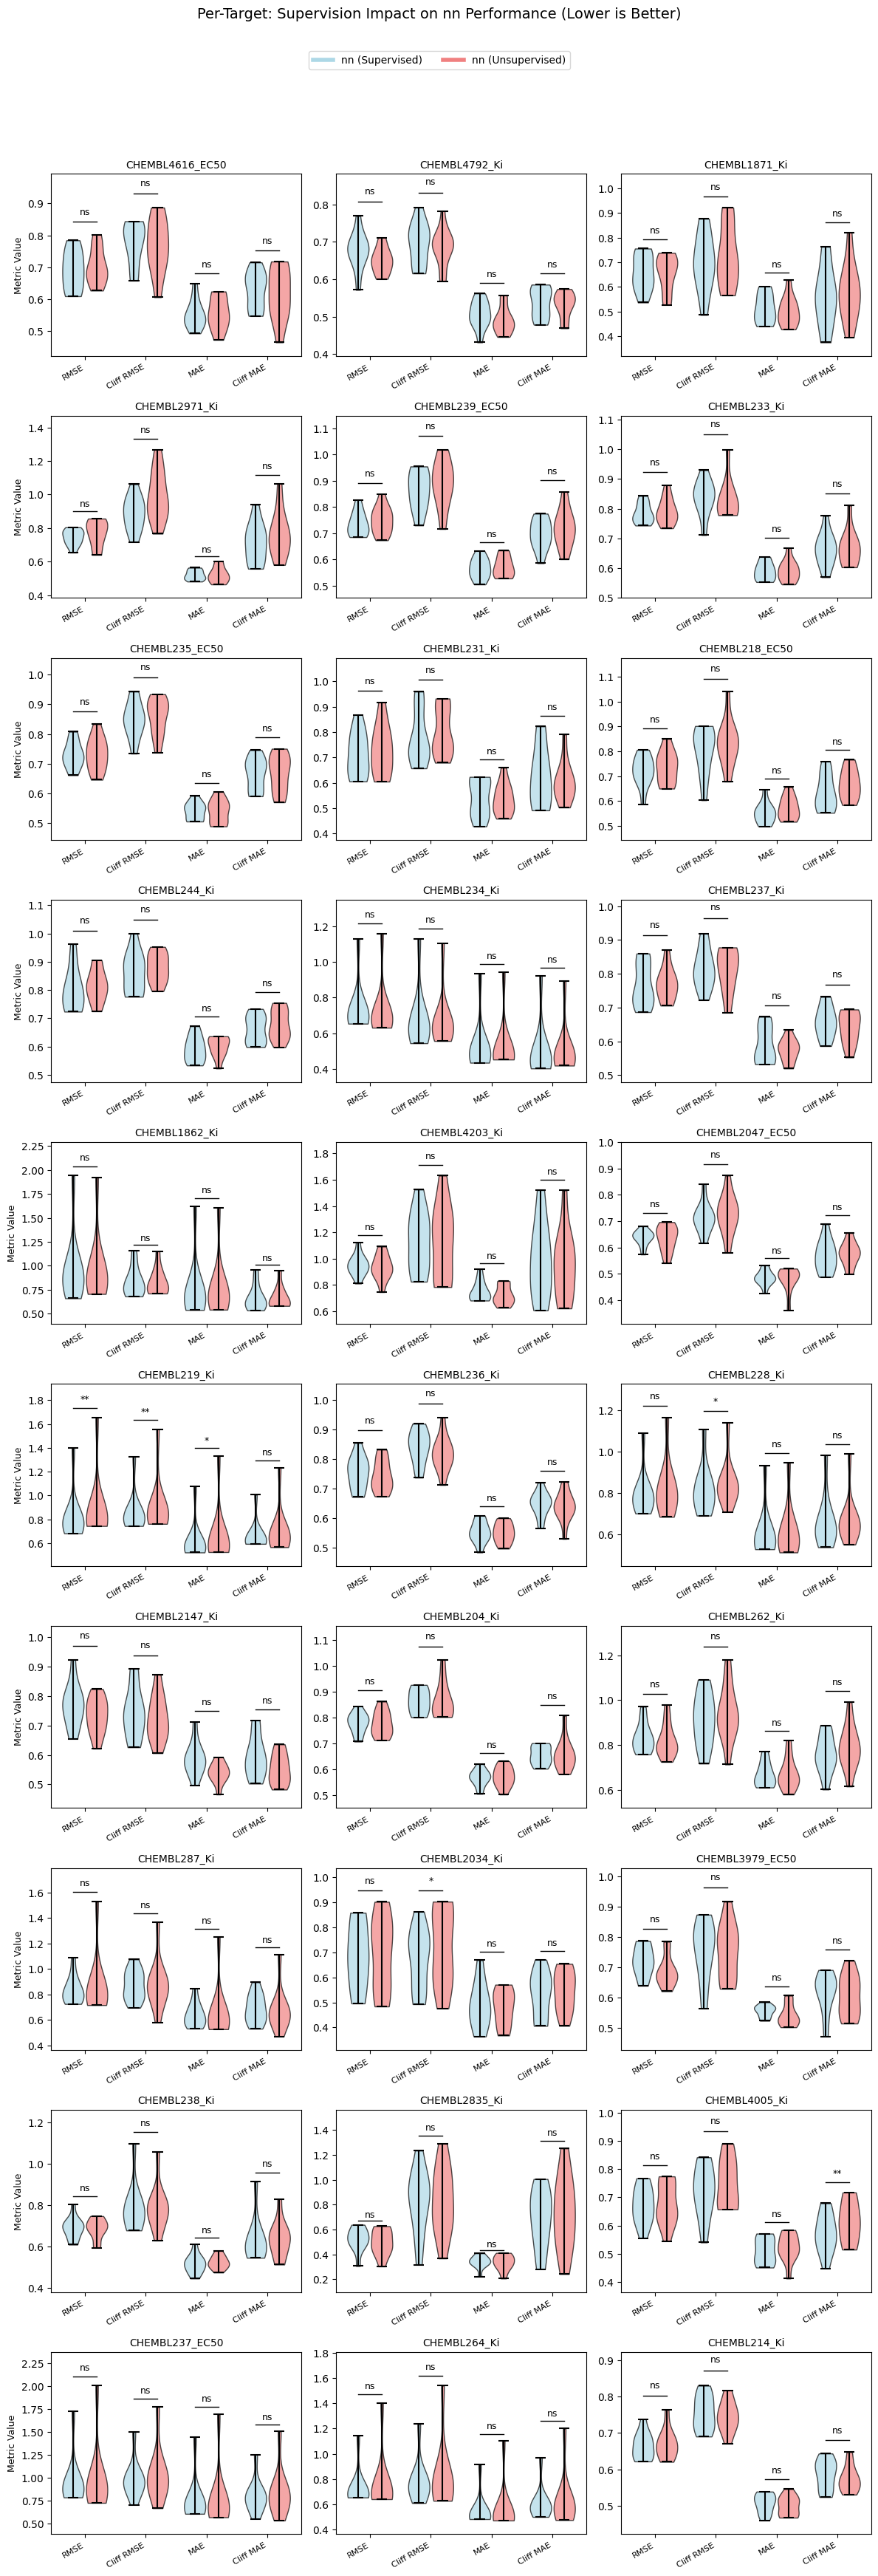


--- 7. Per-Target Paired Wilcoxon Test for nn Value Metrics (Text Summary) ---

Summary for nn:
         Target     Metric  N Pairs  Mean (nn Sup)  Mean (nn Unsup)  p-value (Wilcoxon, Sup < Unsup) nn Sup Better (p<0.05)
  CHEMBL1862_Ki  Cliff MAE       10         0.6643           0.6676                           0.5000                     No
  CHEMBL1862_Ki Cliff RMSE       10         0.8344           0.8342                           0.6152                     No
  CHEMBL1862_Ki        MAE       10         0.7543           0.7689                           0.3477                     No
  CHEMBL1862_Ki       RMSE       10         0.9643           0.9671                           0.5391                     No
  CHEMBL1871_Ki  Cliff MAE       10         0.5614           0.5786                           0.1875                     No
  CHEMBL1871_Ki Cliff RMSE       10         0.6979           0.7265                           0.0527                     No
  CHEMBL1871_Ki        MAE       10

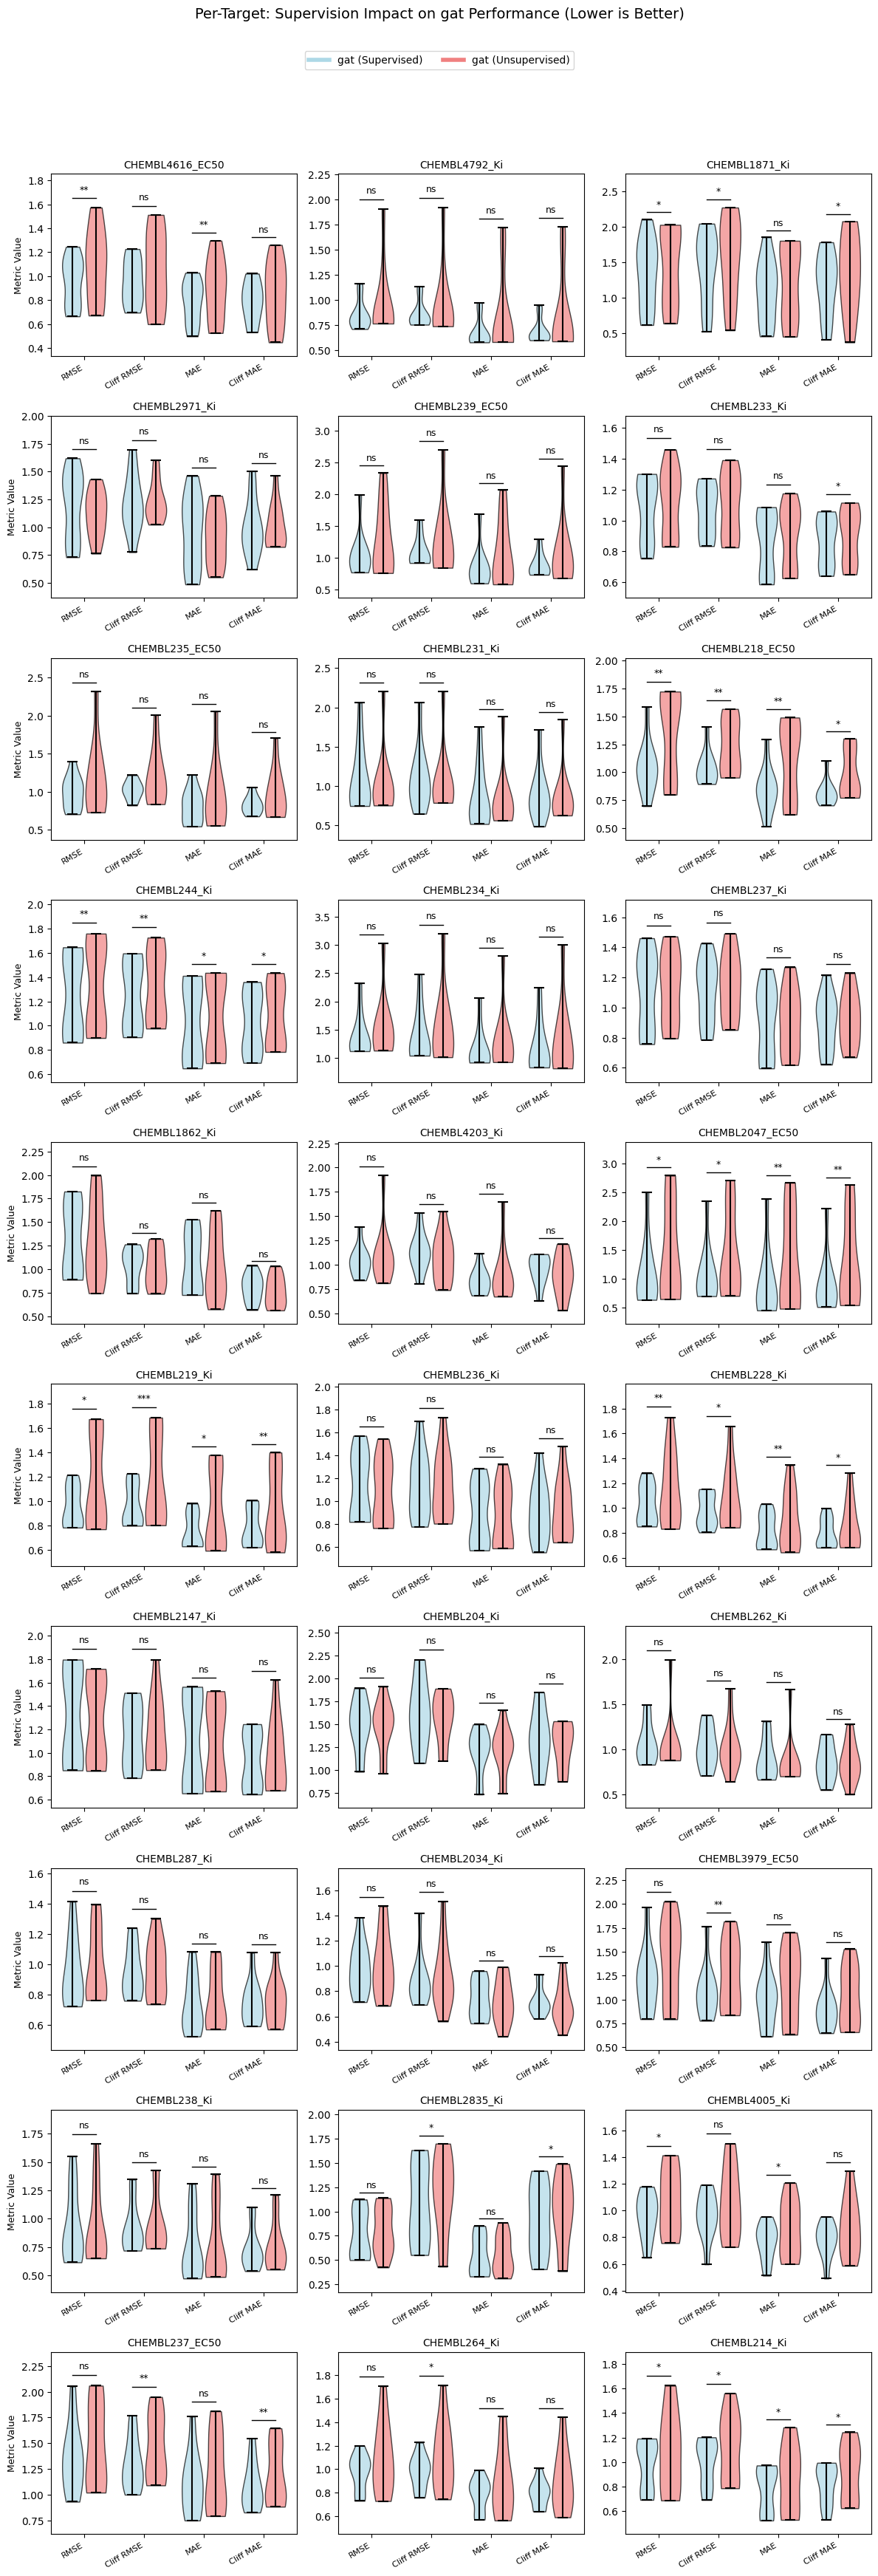


--- 7. Per-Target Paired Wilcoxon Test for gat Value Metrics (Text Summary) ---

Summary for gat:
         Target     Metric  N Pairs  Mean (gat Sup)  Mean (gat Unsup)  p-value (Wilcoxon, Sup < Unsup) gat Sup Better (p<0.05)
  CHEMBL1862_Ki  Cliff MAE       10          0.8068            0.7699                           0.8623                      No
  CHEMBL1862_Ki Cliff RMSE       10          1.0307            1.0153                           0.4229                      No
  CHEMBL1862_Ki        MAE       10          1.0620            1.0269                           0.7539                      No
  CHEMBL1862_Ki       RMSE       10          1.3227            1.2983                           0.7842                      No
  CHEMBL1871_Ki  Cliff MAE       10          1.1885            1.3324                           0.0322                     Yes
  CHEMBL1871_Ki Cliff RMSE       10          1.4242            1.5588                           0.0137                     Yes
  CHEMBL1871

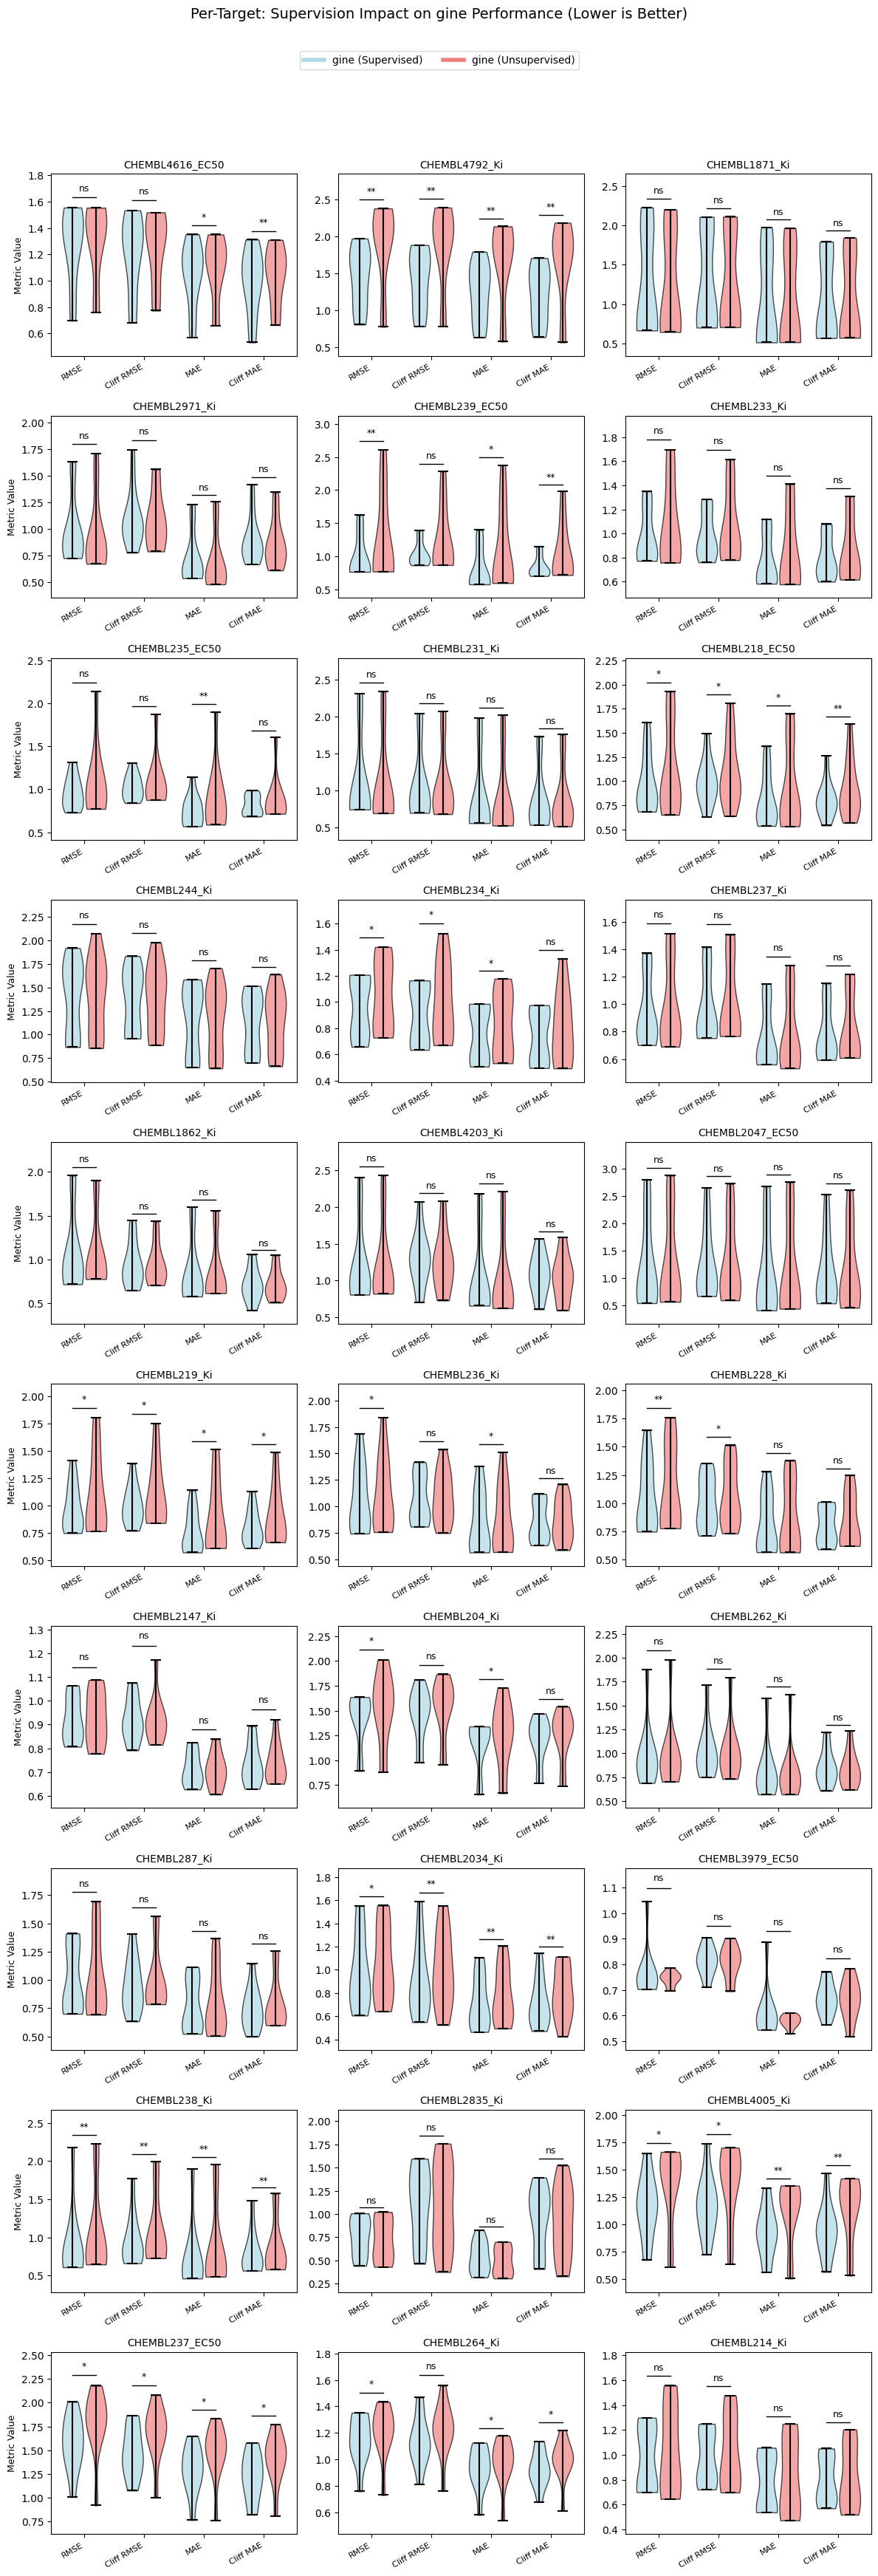


--- 7. Per-Target Paired Wilcoxon Test for gine Value Metrics (Text Summary) ---

Summary for gine:
         Target     Metric  N Pairs  Mean (gine Sup)  Mean (gine Unsup)  p-value (Wilcoxon, Sup < Unsup) gine Sup Better (p<0.05)
  CHEMBL1862_Ki  Cliff MAE       10           0.7112             0.7149                           0.5771                       No
  CHEMBL1862_Ki Cliff RMSE       10           0.9444             0.9414                           0.6152                       No
  CHEMBL1862_Ki        MAE       10           0.8534             0.8383                           0.7842                       No
  CHEMBL1862_Ki       RMSE       10           1.0764             1.0589                           0.7539                       No
  CHEMBL1871_Ki  Cliff MAE       10           1.0678             1.0647                           0.6875                       No
  CHEMBL1871_Ki Cliff RMSE       10           1.2953             1.3045                           0.5771               

In [29]:
# --- MODIFIED SECTION 6 & 7: Per-Target Paired Analysis for NN Value Metrics (Adaptable for Backbones) ---

# --- Helper function to collect data for per-target paired NN value metrics (MODIFIED) ---
def collect_data_for_per_target_paired_nn_value_metrics(
    original_df: pd.DataFrame,
    value_metric_names: list, # e.g., ['test_rmse', 'test_mae']
    nn_method_identifier: str # Specific NN method/backbone name, e.g., 'nn_resnet'
):
    """
    Collects data for per-target paired comparisons of a specific NN method/backbone
    (with supervision vs. without supervision) for specified value-based metrics.
    Uses Wilcoxon signed-rank test.
    """
    if 'target' not in original_df.columns:
        print(f"Error: 'target' column not found. Cannot perform per-target analysis for {nn_method_identifier} value metrics.")
        return {}
    if not value_metric_names:
        print(f"No value metric names provided for per-target paired analysis of {nn_method_identifier}.")
        return {}

    unique_targets = original_df['target'].unique()
    plot_data_collected = {}

    for current_target in unique_targets:
        target_data = {}
        has_data_for_this_target = False
        for val_metric_name in value_metric_names:
            # Filter for the specific NN method/backbone and the value metric
            df_subset_metric = original_df[
                (original_df['target'] == current_target) &
                (original_df['method'] == nn_method_identifier) & # Use nn_method_identifier
                (original_df['metric_name'] == val_metric_name)
            ]

            if df_subset_metric.empty:
                continue

            scores_yes_series = df_subset_metric[df_subset_metric['x_supervis'] == 'yes'] \
                                .set_index('split_seed')['metric_value']
            scores_no_series = df_subset_metric[df_subset_metric['x_supervis'] == 'no'] \
                               .set_index('split_seed')['metric_value']

            merged_scores_df = pd.merge(
                scores_yes_series.rename('metric_value_yes'),
                scores_no_series.rename('metric_value_no'),
                left_index=True,
                right_index=True,
                how='inner'
            )

            if merged_scores_df.shape[0] < 5: 
                continue

            paired_scores_yes = merged_scores_df['metric_value_yes'].tolist()
            paired_scores_no = merged_scores_df['metric_value_no'].tolist()

            p_val = None
            try:
                wilcoxon_result = stats.wilcoxon(paired_scores_yes, paired_scores_no, alternative='less', zero_method='pratt')
                p_val = wilcoxon_result.pvalue
                has_data_for_this_target = True
            except ValueError:
                pass 

            target_data[val_metric_name] = {
                'yes_scores': paired_scores_yes,
                'no_scores': paired_scores_no,
                'p_value': p_val
            }
        
        if has_data_for_this_target and target_data:
            plot_data_collected[current_target] = target_data
            
    return plot_data_collected

# --- Helper function to plot per-target paired NN value metrics violins (MODIFIED) ---
def plot_per_target_paired_nn_value_metrics_violins(
    data_for_plotting: dict,
    all_value_metric_names: list, 
    value_metric_display_names: dict, 
    nn_method_identifier: str, # Specific NN method/backbone name
    alpha_levels=(0.05, 0.01, 0.001, 0.0001),
    figsize_per_subplot=(4, 3.5),
    save_path_template: str | None = "per_target_paired_{}_value_metrics.png", # Template for save path
    base_plot_title: str = "Per-Target: Supervision Impact on {} Performance (Lower is Better)"
):
    """
    Plots per-target paired violins for a specific NN method's value metrics (supervised vs. unsupervised).
    """
    if not data_for_plotting:
        print(f"No data provided for plotting per-target {nn_method_identifier} value metrics.")
        return

    targets = list(data_for_plotting.keys())
    num_targets = len(targets)
    if num_targets == 0:
        print(f"No targets with data to plot for {nn_method_identifier} value metrics.")
        return

    cols = 3 
    rows = math.ceil(num_targets / cols)
    fig_height = rows * figsize_per_subplot[1]
    fig_width = cols * figsize_per_subplot[0]
    if cols < 3 and len(all_value_metric_names) > 2:
        fig_width = max(fig_width, len(all_value_metric_names) * 2.5 * cols)

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), squeeze=False, sharey=False)
    axes = axes.flatten()

    min_y_overall = float('inf')
    max_y_overall = float('-inf')
    for target_name, target_metrics_data in data_for_plotting.items():
        for metric_name_internal in all_value_metric_names:
            metric_data = target_metrics_data.get(metric_name_internal)
            if metric_data and metric_data['yes_scores'] and metric_data['no_scores']:
                min_y_overall = min(min_y_overall, min(metric_data['yes_scores']), min(metric_data['no_scores']))
                max_y_overall = max(max_y_overall, max(metric_data['yes_scores']), max(metric_data['no_scores']))
    if min_y_overall == float('inf'): min_y_overall = 0; max_y_overall = 1

    for i, target_name in enumerate(targets):
        ax = axes[i]
        target_metrics_data = data_for_plotting[target_name]
        x_positions = np.arange(len(all_value_metric_names))
        violin_width = 0.35
        current_min_y_subplot = float('inf')
        current_max_y_subplot = float('-inf')

        for j, metric_name_internal in enumerate(all_value_metric_names):
            metric_data = target_metrics_data.get(metric_name_internal)
            if metric_data and metric_data['yes_scores'] and metric_data['no_scores']:
                scores_yes_val = metric_data['yes_scores']
                scores_no_val = metric_data['no_scores']
                p_val_metric = metric_data['p_value']
                current_min_y_subplot = min(current_min_y_subplot, min(scores_yes_val), min(scores_no_val))
                current_max_y_subplot = max(current_max_y_subplot, max(scores_yes_val), max(scores_no_val))

                parts_yes = ax.violinplot(scores_yes_val, positions=[x_positions[j] - violin_width/2 - 0.02], widths=violin_width, showextrema=True, showmedians=False)
                parts_no = ax.violinplot(scores_no_val, positions=[x_positions[j] + violin_width/2 + 0.02], widths=violin_width, showextrema=True, showmedians=False)
                for pc in parts_yes['bodies']: pc.set_facecolor('lightblue'); pc.set_edgecolor('black'); pc.set_alpha(0.7)
                for partname in ('cbars', 'cmins', 'cmaxes'): parts_yes[partname].set_edgecolor('black')
                for pc in parts_no['bodies']: pc.set_facecolor('lightcoral'); pc.set_edgecolor('black'); pc.set_alpha(0.7)
                for partname in ('cbars', 'cmins', 'cmaxes'): parts_no[partname].set_edgecolor('black')

                if p_val_metric is not None:
                    stars = "ns"
                    if p_val_metric <= alpha_levels[3]: stars = "****"
                    elif p_val_metric <= alpha_levels[2]: stars = "***"
                    elif p_val_metric <= alpha_levels[1]: stars = "**"
                    elif p_val_metric <= alpha_levels[0]: stars = "*"
                    y_max_violins = max(max(scores_yes_val), max(scores_no_val))
                    ax.plot([x_positions[j] - violin_width/2 -0.02, x_positions[j] + violin_width/2+0.02], [y_max_violins * 1.05, y_max_violins * 1.05], lw=1, c='black')
                    ax.text(x_positions[j], y_max_violins * 1.07, stars, ha='center', va='bottom', fontsize=9)
            else:
                ax.text(x_positions[j], (min_y_overall + max_y_overall) / 2 if min_y_overall != float('inf') else 0.5, "N/A", ha='center', va='center', fontsize=8, color='grey')

        ax.set_xticks(x_positions)
        ax.set_xticklabels([value_metric_display_names.get(m, m) for m in all_value_metric_names], rotation=30, ha="right", fontsize=8)
        ax.set_title(target_name, fontsize=10)
        if i % cols == 0: ax.set_ylabel("Metric Value", fontsize=9)
        if current_min_y_subplot != float('inf'):
             y_range = current_max_y_subplot - current_min_y_subplot
             ax.set_ylim(current_min_y_subplot - y_range * 0.1, current_max_y_subplot + y_range * 0.25)
        else:
            ax.set_ylim(min_y_overall - (max_y_overall-min_y_overall)*0.1 if min_y_overall != float('inf') else 0, 
                        max_y_overall + (max_y_overall-min_y_overall)*0.25 if max_y_overall != float('-inf') else 1)

    handles = [plt.Line2D([0], [0], color='lightblue', lw=4, label=f'{nn_method_identifier} (Supervised)'),
               plt.Line2D([0], [0], color='lightcoral', lw=4, label=f'{nn_method_identifier} (Unsupervised)')]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.98 if rows > 1 else 1.06 - (0.02 * rows) ), ncol=2, fontsize=10)
    
    dynamic_plot_title = base_plot_title.format(nn_method_identifier)
    fig.suptitle(dynamic_plot_title, fontsize=14, y=0.995 if rows > 1 else 1.08 - (0.03 * rows))
    plt.tight_layout(rect=[0, 0, 1, 0.95 if rows > 1 else 0.92])
    for j in range(num_targets, rows * cols): fig.delaxes(axes[j])

    if save_path_template:
        # Sanitize nn_method_identifier for use in filename
        sane_method_id = "".join(c if c.isalnum() else "_" for c in nn_method_identifier)
        current_save_path = save_path_template.format(sane_method_id)
        plt.savefig(current_save_path, dpi=300, bbox_inches='tight')
        print(f"Per-target {nn_method_identifier} value metrics plot saved to {current_save_path}")
    plt.show()


# --- Define NN backbones/methods and metrics for this analysis ---
# USER: Replace these with your actual backbone method names as they appear in the 'method' column of df
backbones_to_analyze = ['nn', 'gat', 'gine'] 

value_metrics_config = {
    'metrics_to_analyze': ['test_rmse', 'test_cliff_rmse', 'test_mae', 'test_cliff_mae'],
    'display_names': {
        'test_rmse': 'RMSE',
        'test_cliff_rmse': 'Cliff RMSE',
        'test_mae': 'MAE',
        'test_cliff_mae': 'Cliff MAE'
    }
}

# --- Loop through each backbone for analysis ---
for backbone_method_id in backbones_to_analyze:
    print(f"\n\n--- Analyzing Value Metrics for Backbone: {backbone_method_id} ---")

    # --- SECTION 6 (Plotting) for current backbone ---
    print(f"\n--- 6. Per-Target Paired Violin Plots for {backbone_method_id} Value Metrics ---")
    
    per_target_current_backbone_value_data = collect_data_for_per_target_paired_nn_value_metrics(
        df, 
        value_metrics_config['metrics_to_analyze'],
        nn_method_identifier=backbone_method_id
    )

    if per_target_current_backbone_value_data:
        plot_per_target_paired_nn_value_metrics_violins(
            data_for_plotting=per_target_current_backbone_value_data,
            all_value_metric_names=value_metrics_config['metrics_to_analyze'],
            value_metric_display_names=value_metrics_config['display_names'],
            nn_method_identifier=backbone_method_id,
            # save_path_template is now a parameter of the plot function
        )
    else:
        print(f"No data collected to generate per-target paired {backbone_method_id} value metrics plots.")

    # --- SECTION 7 (Text Summary) for current backbone ---
    print(f"\n--- 7. Per-Target Paired Wilcoxon Test for {backbone_method_id} Value Metrics (Text Summary) ---")

    if 'target' not in df.columns:
        print(f"Error: 'target' column not found. Cannot perform per-target Wilcoxon tests for {backbone_method_id} value metrics.")
    else:
        alpha_val_test = 0.05
        results_summary_current_backbone = []
        
        # Use the data collected for plotting for this backbone
        if per_target_current_backbone_value_data:
            for target_name, metrics_data in per_target_current_backbone_value_data.items():
                for metric_name, data_dict in metrics_data.items():
                    if data_dict['p_value'] is not None: 
                        scores_yes = data_dict['yes_scores']
                        scores_no = data_dict['no_scores']
                        p_value = data_dict['p_value']
                        sig_imp = "Yes" if p_value < alpha_val_test else "No"
                        
                        results_summary_current_backbone.append({
                            "Target": target_name,
                            "Metric": value_metrics_config['display_names'].get(metric_name, metric_name),
                            "N Pairs": len(scores_yes),
                            f"Mean ({backbone_method_id} Sup)": np.mean(scores_yes),
                            f"Mean ({backbone_method_id} Unsup)": np.mean(scores_no),
                            "p-value (Wilcoxon, Sup < Unsup)": p_value,
                            f"{backbone_method_id} Sup Better (p<{alpha_val_test})": sig_imp
                        })
        else:
            print(f"No pre-collected plot data for {backbone_method_id} to use for summary. Summary will be empty or based on re-calculation if implemented.")
            # Optionally, you could re-run a simplified collection here if needed, but reusing is cleaner.

        if results_summary_current_backbone:
            summary_df_current_backbone = pd.DataFrame(results_summary_current_backbone)
            pd.options.display.float_format = '{:.4f}'.format
            print(f"\nSummary for {backbone_method_id}:")
            print(summary_df_current_backbone.sort_values(by=["Target", "Metric"]).to_string(index=False))
            pd.reset_option('display.float_format')
        else:
            print(f"No per-target paired Wilcoxon tests could be performed for {backbone_method_id} value metrics (or all had insufficient pairs).")


print("\nAll analyses complete. Check for generated .png files.")

In [ ]:
def collect_data_for_supervision_effect_plot(
    df_aggregated_by_target: pd.DataFrame,
    attribution_metrics_list: list,
    prediction_metrics_list: list,
    backbone_method_name: str = 'nn'
):
    """
    Collects data for paired comparisons (supervision vs. no supervision) 
    from a DataFrame already aggregated by target.
    """
    attribution_plot_data = {}
    prediction_plot_data = {}

    # Process Attribution Metrics
    for metric_name in attribution_metrics_list:
        df_metric_filtered = df_aggregated_by_target[
            (df_aggregated_by_target['method'] == backbone_method_name) &
            (df_aggregated_by_target['metric_name'] == metric_name)
        ]
        
        scores_no_series = df_metric_filtered[df_metric_filtered['x_supervis'] == 'no'] \
                            .set_index('target')['avg_score_per_target']
        scores_yes_series = df_metric_filtered[df_metric_filtered['x_supervis'] == 'yes'] \
                             .set_index('target')['avg_score_per_target']

        merged_scores = pd.merge(
            scores_no_series.rename('no_supervision'),
            scores_yes_series.rename('yes_supervision'),
            left_index=True,
            right_index=True,
            how='inner' # Ensures only targets present in both are used for pairing
        )

        if not merged_scores.empty and len(merged_scores) >= 2:
            attribution_plot_data[metric_name] = {
                'no_supervision': merged_scores['no_supervision'].tolist(),
                'yes_supervision': merged_scores['yes_supervision'].tolist(),
                'n_pairs': len(merged_scores)
            }

    # Process Prediction Metrics
    for metric_name in prediction_metrics_list:
        df_metric_filtered = df_aggregated_by_target[
            (df_aggregated_by_target['method'] == backbone_method_name) &
            (df_aggregated_by_target['metric_name'] == metric_name)
        ]
        scores_no_series = df_metric_filtered[df_metric_filtered['x_supervis'] == 'no'] \
                            .set_index('target')['avg_score_per_target']
        scores_yes_series = df_metric_filtered[df_metric_filtered['x_supervis'] == 'yes'] \
                             .set_index('target')['avg_score_per_target']

        merged_scores = pd.merge(
            scores_no_series.rename('no_supervision'),
            scores_yes_series.rename('yes_supervision'),
            left_index=True,
            right_index=True,
            how='inner'
        )

        if not merged_scores.empty and len(merged_scores) >= 2:
            prediction_plot_data[metric_name] = {
                'no_supervision': merged_scores['no_supervision'].tolist(),
                'yes_supervision': merged_scores['yes_supervision'].tolist(),
                'n_pairs': len(merged_scores)
            }
            
    return attribution_plot_data, prediction_plot_data

def plot_supervision_effects_violins(
    attribution_data: dict, 
    prediction_data: dict,
    attribution_metric_display_map: dict, # {actual_name: display_name}
    prediction_metric_display_map: dict,  # {actual_name: display_name}
    alpha_levels=(0.05, 0.01, 0.001, 0.0001),
    figsize=(14, 7), 
    save_path: str | None = None,
    plot_suptitle: str = ""
):
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=150) # layout="constrained" can be added
    
    colors = {'no_supervision': 'lightcoral', 'yes_supervision': 'skyblue'}
    group_labels = {'no_supervision': 'GAT', 'yes_supervision': 'ACES-GAT'}
    
    legend_handles = [
        plt.Line2D([0], [0], color=colors['no_supervision'], lw=4, label=group_labels['no_supervision']),
        plt.Line2D([0], [0], color=colors['yes_supervision'], lw=4, label=group_labels['yes_supervision'])
    ]

    plot_config = [
        {
            "ax": axes[0], "data": attribution_data, 
            "ylabel": "Global direction (Higher is Better)", "test_alternative": "greater",
            "metric_display_map": attribution_metric_display_map, "metric_order": list(attribution_metric_display_map.keys())
        },
        {
            "ax": axes[1], "data": prediction_data, 
            "ylabel": "Error (Lower is Better)", "test_alternative": "less",
            "metric_display_map": prediction_metric_display_map, "metric_order": list(prediction_metric_display_map.keys())
        }
    ]

    for config in plot_config:
        ax = config["ax"]
        data_dict = config["data"]
        metric_order = [m for m in config["metric_order"] if m in data_dict] # Plot only available metrics
        
        num_metrics_to_plot = len(metric_order)
        if num_metrics_to_plot == 0:
            ax.text(0.5, 0.5, "No data available", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(config["title"], fontsize=12, fontweight="bold")
            continue

        x_base_positions = np.arange(num_metrics_to_plot)
        violin_width = 0.38
        overall_max_y_subplot = -float('inf')
        overall_min_y_subplot = float('inf')
        subplot_n_pairs = 0

        for i, metric_name in enumerate(metric_order):
            metric_data = data_dict[metric_name]
            scores_no = metric_data['no_supervision']
            scores_yes = metric_data['yes_supervision']
            current_n_pairs = metric_data['n_pairs']
            if i == 0: subplot_n_pairs = current_n_pairs # Use N from first metric for subplot annotation
            elif current_n_pairs != subplot_n_pairs: # If N varies, indicate range or min
                 print(f"Warning: N varies for {config['title']}. Using N={subplot_n_pairs} from first metric for annotation.")


            if not scores_no or not scores_yes: continue

            current_max_y_pair = max(np.max(scores_no), np.max(scores_yes))
            current_min_y_pair = min(np.min(scores_no), np.min(scores_yes))
            overall_max_y_subplot = max(overall_max_y_subplot, current_max_y_pair)
            overall_min_y_subplot = min(overall_min_y_subplot, current_min_y_pair)
            
            positions = {
                'no_supervision': x_base_positions[i] - violin_width/2 - 0.02,
                'yes_supervision': x_base_positions[i] + violin_width/2 + 0.02
            }

            for key, scores_list in [('no_supervision', scores_no), ('yes_supervision', scores_yes)]:
                pos = positions[key]
                color_rgba = mcolors.to_rgba(colors[key], alpha=0.7)
                
                sns.violinplot(y=scores_list, x=[pos]*len(scores_list), ax=ax, orient="v", native_scale=True,
                               width=violin_width, color=color_rgba, edgecolor='black', linewidth=1, inner=None)

                stats_list = cbook.boxplot_stats(scores_list)
                if stats_list:
                    s = stats_list[0]
                    ax.plot([pos, pos], [s['q1'], s['q3']], color='dimgray', linewidth=3, solid_capstyle='butt', zorder=3)
                    ax.plot([pos, pos], [s['whislo'], s['q1']], color='dimgray', linewidth=1, solid_capstyle='butt', zorder=3)
                    ax.plot([pos, pos], [s['q3'], s['whishi']], color='dimgray', linewidth=1, solid_capstyle='butt', zorder=3)
                    ax.plot(pos, s['med'], marker='o', color='white', markeredgecolor='black', markersize=5, zorder=4)
            
            # Statistical test
            p_value = 1.0
            try:
                _, p_value = stats.wilcoxon(scores_yes, scores_no, alternative=config["test_alternative"], zero_method='wilcox')
            except ValueError as e:
                print(f"Wilcoxon test failed for {metric_name}: {e}")
            
            stars = "ns"
            if p_value <= alpha_levels[3]: stars = "****"
            elif p_value <= alpha_levels[2]: stars = "***"
            elif p_value <= alpha_levels[1]: stars = "**"
            elif p_value <= alpha_levels[0]: stars = "*"
            
            # Annotation for significance
            # Adjust y_pos for annotation dynamically
            annotation_y_start = current_max_y_pair 
            ax_current_ymin, ax_current_ymax = ax.get_ylim()
            if not np.isfinite(ax_current_ymax) or ax_current_ymax == ax_current_ymin : # if ylim not set well yet
                 plot_height_est = overall_max_y_subplot - overall_min_y_subplot if overall_max_y_subplot > overall_min_y_subplot else 1.0
            else:
                 plot_height_est = ax_current_ymax - ax_current_ymin

            y_offset_factor = 0.03 * plot_height_est 
            bar_height = 0.01 * plot_height_est
            
            line_y_level = annotation_y_start + y_offset_factor 
            
            ax.plot([positions['no_supervision'], positions['yes_supervision']], 
                    [line_y_level, line_y_level], lw=1.0, c='black')
            ax.plot([positions['no_supervision'], positions['no_supervision']], 
                    [line_y_level - bar_height/2, line_y_level], lw=1.0, c='black')
            ax.plot([positions['yes_supervision'], positions['yes_supervision']], 
                    [line_y_level - bar_height/2, line_y_level], lw=1.0, c='black')
            ax.text((positions['no_supervision'] + positions['yes_supervision']) / 2, 
                    line_y_level + bar_height*0.1, stars, 
                    ha='center', va='bottom', color='black', fontsize=9)
            
            overall_max_y_subplot = max(overall_max_y_subplot, line_y_level + bar_height * 1.5)


        ax.set_xticks(x_base_positions)
        ax.set_xticklabels([config["metric_display_map"].get(m, m) for m in metric_order], rotation=35, ha="right", fontsize=9)
        ax.set_ylabel(config["ylabel"], fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        '''
        if np.isfinite(overall_max_y_subplot) and np.isfinite(overall_min_y_subplot):
            padding_factor = 0.15 # Increased padding for annotations
            current_ymin = overall_min_y_subplot
            if config["ylabel"] == "Accuracy (Higher is Better)": # Typically 0-1 range
                current_ymin = min(0, overall_min_y_subplot) # Ensure y starts at 0 or less for accuracy
            
            ax.set_ylim(current_ymin - (overall_max_y_subplot-current_ymin)*0.05, overall_max_y_subplot + (overall_max_y_subplot-current_ymin)*padding_factor)
        '''
        if subplot_n_pairs > 0:
            ax.text(0.98, 0.02, f"N = {subplot_n_pairs}", ha="right", va="bottom", 
                    transform=ax.transAxes, fontsize=8, color='dimgray')

    fig.legend(handles=legend_handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.99), fontsize=10)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect for suptitle and legend
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Plot saved to {save_path}")
    plt.show()

# --- Define metrics and display names ---
# Attribution metrics from nn_attribution_metrics_for_test in cell [17]
# ['gradcam_acc', 'smoothgrad_acc', 'inputxgrad_acc', 'ig_acc']
attribution_metrics_plot = ['gradcam_acc', 'smoothgrad_acc', 'inputxgrad_acc', 'ig_acc', 'mask_acc']
attribution_display_names = {
    'gradcam_acc': 'GradCAM',
    'smoothgrad_acc': 'SmoothGrad',
    'inputxgrad_acc': 'GradInput',
    'ig_acc': 'IG',
    'mask_acc': 'Mask'
}
df_avg_by_target = df.groupby(['target', 'method', 'x_supervis', 'metric_name'])['metric_value'] \
                     .mean() \
                     .reset_index() \
                     .rename(columns={'metric_value': 'avg_score_per_target'})
# Prediction metrics
prediction_metrics_plot = ['test_rmse', 'test_cliff_rmse', 'test_mae', 'test_cliff_mae']
prediction_display_names = {
    'test_rmse': 'RMSE$_{all}$',
    'test_cliff_rmse': 'RMSE$_{cliff}$',
    'test_mae': 'MAE$_{all}$',
    'test_cliff_mae': 'MAE$_{cliff}$'
}
# --- Collect data ---
BACKBONE_GNN = 'nn'
attr_data_for_plot, pred_data_for_plot = collect_data_for_supervision_effect_plot(
    df_avg_by_target, 
    attribution_metrics_plot,
    prediction_metrics_plot,
    backbone_method_name=BACKBONE_GNN 
)

# --- Generate plot ---
if attr_data_for_plot or pred_data_for_plot: # Check if there's any data to plot
    plot_supervision_effects_violins(
        attribution_data=attr_data_for_plot,
        prediction_data=pred_data_for_plot,
        attribution_metric_display_map=attribution_display_names,
        prediction_metric_display_map=prediction_display_names,
        save_path=""#f"supervision_effects_comparison_{BACKBONE_GNN}.pdf"
    )
else:
    print("No data collected for the supervision effects plot. Please check metric names and data.")



Ablation plot saved to ablation_studies.pdf


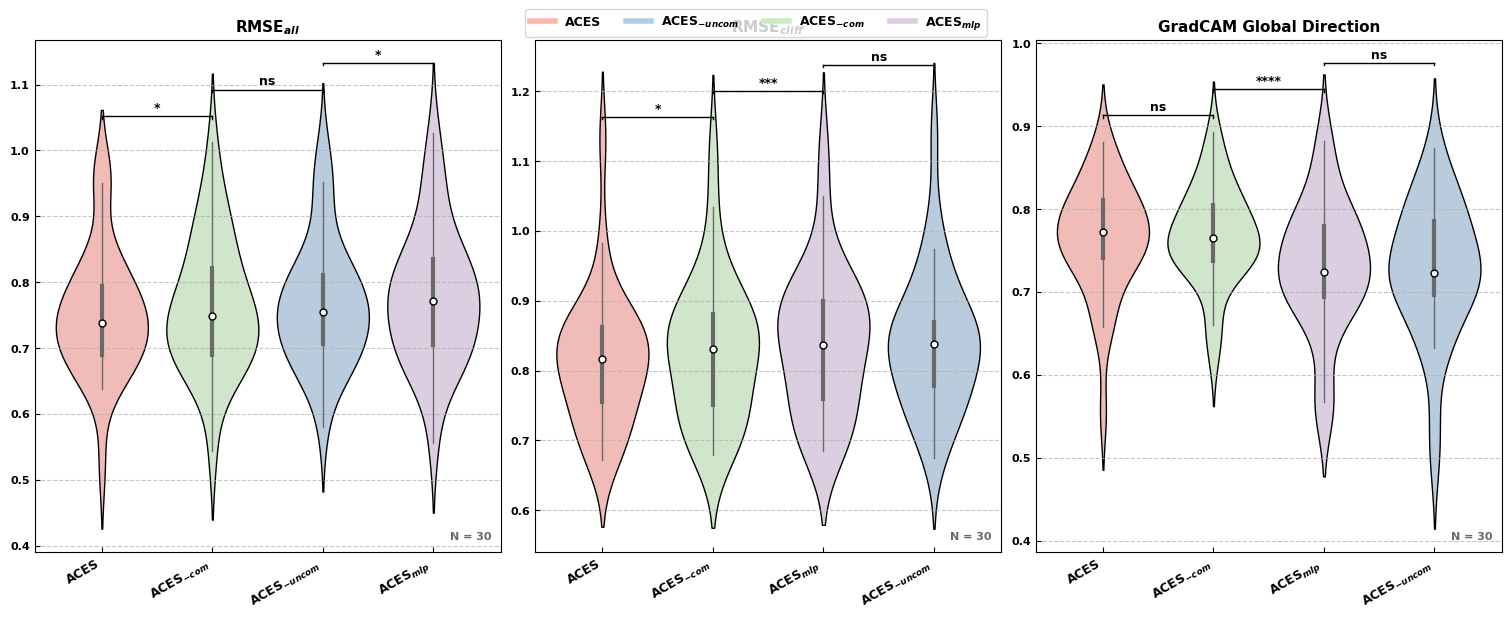

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cbook as cbook

# Assume df_avg_by_target is already computed and available
# Assume BACKBONE_GNN is defined if needed for method names

def plot_ablation_study_violins(
    df_aggregated_by_target: pd.DataFrame,
    ablation_method_identifiers: list,
    metrics_config: dict, # e.g., {'test_rmse': {'display': 'RMSE', 'lower_is_better': True}, ...}
    method_display_names: dict | None = None, # Optional: {'internal_id': 'Display Name'}
    sort_violins_by_median: bool = True,
    test_mode: str = "sequential", # "sequential" or "reference_vs_others"
    reference_method_identifier: str | None = None, # Required if test_mode is "reference_vs_others"
    alpha_levels=(0.05, 0.01, 0.001, 0.0001),
    figsize_per_metric=(5, 6), # Width, Height per subplot
    save_path: str | None = None,
    plot_suptitle: str = "",
    colormap_name: str = 'Set3'
):
    """
    Plots violin comparisons for ablation studies across multiple metrics.
    Ensures that for each metric, comparisons are made on common targets.
    """
    if not ablation_method_identifiers or len(ablation_method_identifiers) < 2:
        print("Error: At least two ablation method identifiers are required.")
        return
    if not metrics_config:
        print("Error: metrics_config cannot be empty.")
        return
    if test_mode == "reference_vs_others" and not reference_method_identifier:
        print("Error: reference_method_identifier is required for 'reference_vs_others' test mode.")
        return
    if reference_method_identifier and reference_method_identifier not in ablation_method_identifiers:
        print(f"Error: reference_method_identifier '{reference_method_identifier}' not in ablation_method_identifiers.")
        return

    # --- 1. Data Preparation: Collect scores for common targets for each metric ---
    data_for_plotting = {} # {actual_metric_name: {'scores': {method_id: [values]}, 'n_common': int}}
    
    actual_metric_names_to_plot = list(metrics_config.keys())

    for actual_metric_name in actual_metric_names_to_plot:
        scores_by_method_series = {} # {method_id: pd.Series(scores, index=targets)}
        for method_id in ablation_method_identifiers:
            condition = (df_aggregated_by_target['method'] == method_id) & \
                        (df_aggregated_by_target['x_supervis'] == 'yes') & \
                        (df_aggregated_by_target['metric_name'] == actual_metric_name)
            
            # Check if 'x_supervis' column exists and handle if necessary
            # For ablation, we usually assume 'x_supervis' is fixed or irrelevant for the method_id
            # If your ablation 'method' identifiers implicitly define supervision status, this is fine.
            # If 'method' can have different 'x_supervis' and you need to specify, adjust filtering here.
            
            metric_scores_for_method = df_aggregated_by_target[condition]
            if not metric_scores_for_method.empty:
                # Ensure unique targets if multiple entries exist (should not with df_avg_by_target)
                metric_scores_for_method = metric_scores_for_method.drop_duplicates(subset=['target'])
                scores_by_method_series[method_id] = metric_scores_for_method.set_index('target')['avg_score_per_target']

        if len(scores_by_method_series) < 1: # Need at least one method with data for the metric
            print(f"Skipping metric '{actual_metric_name}': No data found for any specified ablation methods.")
            continue

        # Find common targets for this metric across all methods that have data for it
        common_targets = None
        methods_with_data_for_metric = list(scores_by_method_series.keys())
        
        if not methods_with_data_for_metric:
            continue

        first_method_series = scores_by_method_series[methods_with_data_for_metric[0]]
        common_targets = set(first_method_series.index)

        for i in range(1, len(methods_with_data_for_metric)):
            method_id_to_check = methods_with_data_for_metric[i]
            common_targets.intersection_update(set(scores_by_method_series[method_id_to_check].index))
        
        common_targets = sorted(list(common_targets))

        if not common_targets or len(common_targets) < 2 : # Need at least 2 common samples for meaningful stats
            print(f"Skipping metric '{actual_metric_name}': Insufficient common targets (found {len(common_targets)}) across methods.")
            continue

        # Collect scores for common targets
        metric_subplot_data = {}
        for method_id in methods_with_data_for_metric: # Only iterate over methods that had data initially
            # Ensure the series is not empty and common_targets exist in its index
            if not scores_by_method_series[method_id].loc[scores_by_method_series[method_id].index.isin(common_targets)].empty:
                 filtered_scores = scores_by_method_series[method_id][common_targets].tolist()
                 if filtered_scores: # Ensure list is not empty after filtering
                    metric_subplot_data[method_id] = filtered_scores
            
        if len(metric_subplot_data) >= 2: # Need at least two methods with data on common targets
            data_for_plotting[actual_metric_name] = {
                'scores': metric_subplot_data,
                'n_common': len(common_targets)
            }
        else:
            print(f"Skipping metric '{actual_metric_name}': Not enough methods with data on common targets.")


    plottable_metrics = list(data_for_plotting.keys())
    if not plottable_metrics:
        print("No data available to plot after processing common targets. Aborting plot generation.")
        return

    num_subplots = len(plottable_metrics)
    fig, axes = plt.subplots(1, num_subplots, 
                             figsize=(figsize_per_metric[0] * num_subplots, figsize_per_metric[1]), 
                             squeeze=False, layout="constrained")
    axes = axes.flatten() # Ensure axes is always a 1D array

    # Define colors for ablation methods
    try:
        cmap = matplotlib.colormaps[colormap_name]
        palette = cmap.colors
    except AttributeError: # Older matplotlib
        cmap = plt.cm.get_cmap(colormap_name)
        palette = cmap.colors
    except KeyError:
        print(f"Warning: Colormap '{colormap_name}' not found. Using default.")
        prop_cycle = plt.rcParams['axes.prop_cycle']
        palette = prop_cycle.by_key()['color']
    
    # Use all initially provided ablation_method_identifiers for consistent color mapping
    # even if some don't have data for a particular metric.
    method_colors = {
        name: palette[i % len(palette)] 
        for i, name in enumerate(ablation_method_identifiers)
    }
    
    legend_handles = {}

    # --- 2. Plotting Loop for each metric ---
    for i, actual_metric_name in enumerate(plottable_metrics):
        ax = axes[i]
        metric_plot_data = data_for_plotting[actual_metric_name]['scores'] # {method_id: [scores]}
        n_common_for_metric = data_for_plotting[actual_metric_name]['n_common']
        
        # Methods that actually have data for *this* metric on common targets
        current_methods_in_plot = list(metric_plot_data.keys()) 
        if not current_methods_in_plot or len(current_methods_in_plot) < 1: # Should be caught earlier, but double check
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(metrics_config[actual_metric_name]['display'], fontsize=11, fontweight="bold")
            continue

        # Sort violins if requested
        group_order_for_metric = list(current_methods_in_plot) # Start with methods that have data
        if sort_violins_by_median and len(group_order_for_metric) > 1:
            medians = {gn: np.median(scores) for gn, scores in metric_plot_data.items() if scores}
            sort_asc = metrics_config[actual_metric_name].get('lower_is_better', True)
            group_order_for_metric.sort(key=lambda gn: medians.get(gn, np.inf if sort_asc else -np.inf), reverse=not sort_asc)

        num_groups_for_this_metric = len(group_order_for_metric)
        violin_base_width = 0.8 
        actual_violin_width = violin_base_width / num_groups_for_this_metric * 0.9 if num_groups_for_this_metric > 0 else violin_base_width * 0.9
        
        plotted_group_x_positions = {}
        max_y_overall_subplot = -float('inf')
        min_y_overall_subplot = float('inf')

        for j, method_id in enumerate(group_order_for_metric):
            scores = metric_plot_data.get(method_id)
            if not scores: continue

            max_y_overall_subplot = max(max_y_overall_subplot, np.max(scores))
            min_y_overall_subplot = min(min_y_overall_subplot, np.min(scores))

            current_violin_x = j * (actual_violin_width * 1.2) # Base position for this violin

            color_rgb = method_colors.get(method_id, "gray") # Fallback color
            color_rgba = mcolors.to_rgba(color_rgb, alpha=0.7)

            sns.violinplot(x=[current_violin_x] * len(scores), y=scores, ax=ax, orient="v", native_scale=True,
                           width=actual_violin_width, color=color_rgba, edgecolor='black', linewidth=1, inner=None)
            
            stats_list = cbook.boxplot_stats(scores)
            if stats_list:
                s = stats_list[0]
                ax.plot([current_violin_x, current_violin_x], [s['q1'], s['q3']], color='dimgray', linewidth=3, zorder=3)
                ax.plot([current_violin_x, current_violin_x], [s['whislo'], s['q1']], color='dimgray', linewidth=1, zorder=3)
                ax.plot([current_violin_x, current_violin_x], [s['q3'], s['whishi']], color='dimgray', linewidth=1, zorder=3)
                ax.plot(current_violin_x, s['med'], marker='o', color='white', markeredgecolor='black', markersize=5, zorder=4)
            
            plotted_group_x_positions[method_id] = current_violin_x
            
            # Prepare legend handles (use original method_id for lookup in method_display_names if provided)
            display_name_for_legend = method_display_names.get(method_id, method_id) if method_display_names else method_id
            if method_id not in legend_handles: # Only add once
                legend_handles[method_id] = plt.Line2D([0], [0], color=color_rgb, lw=4, label=display_name_for_legend)
        
        # --- Statistical Annotations ---
        if len(group_order_for_metric) >= 2:
            # Use Wilcoxon rank-sum test for independent groups
            test_fun = lambda a, b: stats.ttest_rel(a, b, alternative="less" if metrics_config[actual_metric_name].get('lower_is_better', True) else "greater") # Default two-sided for general comparison

            subplot_data_span = max_y_overall_subplot - min_y_overall_subplot
            if subplot_data_span <= 1e-9: subplot_data_span = abs(max_y_overall_subplot) * 0.5 or 1.0

            annotation_start_y_base = max_y_overall_subplot
            annotation_offset_from_data = 0.05 * subplot_data_span
            annotation_increment_y = 0.08 * subplot_data_span
            bar_height = 0.015 * subplot_data_span
            text_lift_from_line = 0.005 * subplot_data_span
            estimated_text_height = 0.04 * subplot_data_span

            annotation_idx = 0
            
            # Determine pairs for testing
            test_pairs = []
            if test_mode == "sequential":
                for k_idx in range(len(group_order_for_metric) - 1):
                    test_pairs.append((group_order_for_metric[k_idx], group_order_for_metric[k_idx+1]))
            elif test_mode == "reference_vs_others" and reference_method_identifier in plotted_group_x_positions:
                ref_id = reference_method_identifier
                for other_id in group_order_for_metric:
                    if other_id != ref_id and other_id in plotted_group_x_positions:
                        test_pairs.append((ref_id, other_id)) # Or (other_id, ref_id) - order for ranksums doesn't change p-value

            for group1_id, group2_id in test_pairs:
                scores1 = metric_plot_data.get(group1_id)
                scores2 = metric_plot_data.get(group2_id)

                if not scores1 or not scores2 or len(scores1) < 2 or len(scores2) < 2: continue

                try:
                    # For ranksums, alternative can be 'two-sided', 'less', 'greater'
                    # If you want to test a directional hypothesis (e.g., is group2 better than group1)
                    # you'd need to define "better" based on metrics_config[actual_metric_name]['lower_is_better']
                    # and potentially adjust the order of scores1, scores2 passed to test_fun.
                    # For simplicity here, using two-sided.
                    stat_val, p_value = test_fun(scores1, scores2)
                except ValueError as e:
                    print(f"Skipping test between {group1_id} and {group2_id} for {actual_metric_name}: {e}")
                    continue
                
                stars = "ns"
                if p_value <= alpha_levels[3]: stars = "****"
                elif p_value <= alpha_levels[2]: stars = "***"
                elif p_value <= alpha_levels[1]: stars = "**"
                elif p_value <= alpha_levels[0]: stars = "*"
                
                x1_pos = plotted_group_x_positions[group1_id]
                x2_pos = plotted_group_x_positions[group2_id]
                
                line_y_level = annotation_start_y_base + annotation_offset_from_data + (annotation_idx * annotation_increment_y)
                
                ax.plot([x1_pos, x2_pos], [line_y_level, line_y_level], lw=1, color="black")
                ax.plot([x1_pos, x1_pos], [line_y_level - bar_height/2, line_y_level], lw=1, color="black")
                ax.plot([x2_pos, x2_pos], [line_y_level - bar_height/2, line_y_level], lw=1, color="black")
                
                text_y = line_y_level + text_lift_from_line
                ax.text((x1_pos + x2_pos) / 2, text_y, stars, ha="center", va="bottom", fontsize=9)
                
                max_y_overall_subplot = max(max_y_overall_subplot, text_y + estimated_text_height)
                annotation_idx += 1

        # --- Subplot Finalization ---
        ax.set_xticks([plotted_group_x_positions[method_id] for method_id in group_order_for_metric if method_id in plotted_group_x_positions])
        
        xtick_labels_display = []
        for method_id in group_order_for_metric:
            if method_id in plotted_group_x_positions:
                 xtick_labels_display.append(method_display_names.get(method_id, method_id) if method_display_names else method_id)

        ax.set_xticklabels(xtick_labels_display, rotation=30, ha="right", fontsize=9)
        
        ax.set_title(metrics_config[actual_metric_name]['display'], fontsize=11, fontweight="bold")
        #ax.set_ylabel("Score", fontsize=10) # Generic Y-label, title indicates metric
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        '''
        # Adjust Y limits
        current_ymin_subplot = min_y_overall_subplot
        if metrics_config[actual_metric_name].get('display', '').lower().startswith("acc"): # For accuracy, try to start near 0
            current_ymin_subplot = min(0.0, min_y_overall_subplot)
        
        ax.set_ylim(current_ymin_subplot - 0.05 * subplot_data_span, max_y_overall_subplot + 0.05 * subplot_data_span)
        '''
        ax.text(0.98, 0.02, f"N = {n_common_for_metric}", ha="right", va="bottom", 
                transform=ax.transAxes, fontsize=8, color='dimgray')

    # --- Figure Finalization ---
    if legend_handles:
        # Order legend handles based on the initial ablation_method_identifiers for consistency
        ordered_legend_items = [legend_handles[name] for name in ablation_method_identifiers if name in legend_handles]
        if ordered_legend_items:
            fig.legend(handles=ordered_legend_items, loc='upper center', 
                       bbox_to_anchor=(0.5, 1.00 + (0.05 / num_subplots)), # Adjust based on suptitle presence
                       ncol=min(len(ordered_legend_items), 4), fontsize=9) # Max 4 columns for legend

    if plot_suptitle:
        fig.suptitle(plot_suptitle, fontsize=14, fontweight='bold', y=1.00 + (0.08 / num_subplots)) # Adjust y based on legend

    # plt.tight_layout(rect=[0, 0, 1, 0.95 if plot_suptitle or legend_handles else 1]) # Adjust for suptitle/legend
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Ablation plot saved to {save_path}")
    plt.show()

ablation_ids = ['nn', 'uncom_ablation', 'com_ablation', 'nn_mlp_att']
ablation_metrics_to_plot_config = {
    'test_rmse': {'display': 'RMSE$_{all}$', 'lower_is_better': True},
    'test_cliff_rmse': {'display': 'RMSE$_{cliff}$', 'lower_is_better': True},
    'gradcam_acc': {'display': 'GradCAM Global Direction', 'lower_is_better': False} # Higher is better for accuracy
}
ablation_display_names = {
    'nn': 'ACES',
    'uncom_ablation': 'ACES$_{-uncom}$',
    'com_ablation': 'ACES$_{-com}$',
    'nn_mlp_att': 'ACES$_{mlp}$',
}
df_avg_by_target = df.groupby(['target', 'method', 'x_supervis', 'metric_name'])['metric_value'] \
                     .mean() \
                     .reset_index() \
                     .rename(columns={'metric_value': 'avg_score_per_target'})
plot_ablation_study_violins(
    df_aggregated_by_target=df_avg_by_target,
    ablation_method_identifiers=ablation_ids,
    metrics_config=ablation_metrics_to_plot_config,
    method_display_names=ablation_display_names, # Optional
    sort_violins_by_median=True,
    test_mode="sequential", # or "reference_vs_others"
    # reference_method_identifier='model_baseline', # if test_mode is "reference_vs_others"
    plot_suptitle="",
    save_path="ablation_studies.pdf",
    colormap_name='Pastel1' 
)